In [ ]:
import sys
print(sys.version)


3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:

# @title 0) Instalación y configuración (sin scikit-plot; con utilidades de plotting)
!pip -q install \
  sentence-transformers \
  scikit-learn \
  imbalanced-learn \
  xgboost \
  matplotlib \
  umap-learn \
  pandas \
  openpyxl \
  ipywidgets \
  pdfplumber \
  pdfminer.six \
  pypdf \
  rapidfuzz \
  tqdm \
  gradio

from google.colab import output
output.enable_custom_widget_manager()

# ---- Imports base
import os, sys, io, json, random, warnings, platform
from datetime import datetime
import numpy as np
import pandas as pd

# ---- ML / CV / Métricas
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import (
    classification_report, accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# ---- NLP
from sentence_transformers import SentenceTransformer, util

# ---- Visualización
import matplotlib.pyplot as plt
import umap

# ---- PDF hooks
import pdfplumber
from pdfminer.high_level import extract_text as pdfminer_extract_text
from pypdf import PdfReader

# ---- Utils
from tqdm import tqdm
from rapidfuzz import fuzz, process as rf_process
from google.colab import files

import gradio as gr  # 🔹 nuevo: para la interfaz web

# ---- Semillas
GLOBAL_RANDOM_SEED = 42
def set_seeds(seed=GLOBAL_RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

set_seeds()

# ---- Dispositivo
def get_device():
    try:
        import torch
        return "cuda" if torch.cuda.is_available() else "cpu"
    except Exception:
        return "cpu"
DEVICE = get_device()

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)

ROOT_DIR = "/content"
ARTIFACTS_DIR = os.path.join(ROOT_DIR, "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ---- Reporte de versiones
def _v(pkg):
    try:
        mod = __import__(pkg)
        return getattr(mod, "__version__", "N/A")
    except Exception:
        return "N/A"

print("Entorno")
print("─"*70)
print(f"Python: {platform.python_version()}  |  SO: {platform.platform()}")
print(f"Fecha: {datetime.now().isoformat(timespec='seconds')}  |  DEVICE: {DEVICE}")
print("Paquetes clave:")
for p in ["numpy","pandas","scikit_learn","imbalanced_learn","xgboost","sentence_transformers","matplotlib","umap"]:
    print(f"  - {p} = {_v(p)}")

# ---- Funciones auxiliares de plotting (sustituyen a scikit-plot)
def plot_confusion_matrix(cm, class_names=("No riesgo","Riesgo")):
    fig, ax = plt.subplots(figsize=(4.2, 3.6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    ax.set_title("Matriz de confusión")
    plt.show()

def plot_roc_pr(y_true, y_prob):
    # ROC
    RocCurveDisplay.from_predictions(y_true, y_prob)
    plt.title("Curva ROC")
    plt.show()
    # PR
    PrecisionRecallDisplay.from_predictions(y_true, y_prob)
    plt.title("Curva Precision–Recall")
    plt.show()

def plot_calibration(y_true, y_prob, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    plt.plot(mean_pred, frac_pos, marker='o')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("Probabilidad predicha")
    plt.ylabel("Frecuencia observada")
    plt.title("Curva de calibración")
    plt.show()
    print("Brier score:", brier_score_loss(y_true, y_prob))

print("\n✅ Entorno listo (sin scikit-plot, con Gradio). Puedes continuar con la Sección 1) Ingesta.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.6/329.6 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.0 MB/s eta 0:00:00


Entorno
──────────────────────────────────────────────────────────────────────
Python: 3.12.12  |  SO: Linux-6.6.105+-x86_64-with-glibc2.35
Fecha: 2025-12-21T21:01:04  |  DEVICE: cpu
Paquetes clave:
  - numpy = 2.0.2
  - pandas = 2.2.2
  - scikit_learn = N/A
  - imbalanced_learn = N/A
  - xgboost = 3.1.2
  - sentence_transformers = 5.2.0
  - matplotlib = 3.10.0
  - umap = 0.5.9.post2

✅ Entorno listo (sin scikit-plot, con Gradio). Puedes continuar con la Sección 1) Ingesta.


In [3]:
# @title 1) Ingesta de datos etiquetados (subir, validar y dejar listo `df_clean`)
# Sube un único archivo: Excel (.xlsx) o CSV (.csv). Debe traer al menos:
# ID, Texto, Es_riesgo. Opcionales: L1_Codigo, L1_Nombre, L2_Codigo, L2_Nombre, Doc_ID, Página, Sección, Fuente, Fase_sugerida, Impacto_dom, Notas

import io, json, re, numpy as np, pandas as pd
from google.colab import files

# ─────────────────────────────────────────────────────────────────────────────
# 1. Subir archivo
print("Selecciona tu dataset etiquetado (Excel .xlsx o CSV .csv)…")
uploaded = files.upload()
if not uploaded:
    raise SystemExit("No se subió ningún archivo.")

fname = list(uploaded.keys())[0]
content = uploaded[fname]
is_excel = fname.lower().endswith(".xlsx")
is_csv   = fname.lower().endswith(".csv")

# ─────────────────────────────────────────────────────────────────────────────
# 2. Leer archivo a DataFrame
if is_excel:
    df = pd.read_excel(io.BytesIO(content))
elif is_csv:
    # para CSV intentamos utf-8 y fallback a latin-1 si falla
    try:
        df = pd.read_csv(io.BytesIO(content))
    except UnicodeDecodeError:
        df = pd.read_csv(io.BytesIO(content), encoding="latin-1")
else:
    raise ValueError("Formato no soportado. Carga un .xlsx o .csv")

print("Columnas detectadas:", list(df.columns))

# ─────────────────────────────────────────────────────────────────────────────
# 3. Normalizar nombres de columnas (tolerante a mayúsculas/acentos/espacios)
def norm_col(c):
    c = str(c).strip()
    c = c.replace("í","i").replace("ó","o").replace("á","a").replace("é","e").replace("ú","u").replace("ñ","n")
    c = re.sub(r"[^A-Za-z0-9_ ]+","", c)
    c = c.strip().replace(" ","_").lower()
    return c

orig_cols = list(df.columns)
df.columns = [norm_col(c) for c in df.columns]

# Mapa deseado -> alias admitidos
ALIASES = {
    "id": {"id"},
    "texto": {"texto","oracion","frase","sentence"},
    "es_riesgo": {"es_riesgo","label","etiqueta","riesgo"},
    "l1_codigo": {"l1_codigo","l1","macro","categoria_rbs","categoria"},
    "l1_nombre": {"l1_nombre"},
    "l2_codigo": {"l2_codigo","subcategoria_rbs","subcategoria"},
    "l2_nombre": {"l2_nombre"},
    "doc_id": {"doc_id","documento","doc"},
    "pagina": {"pagina","página","page"},
    "seccion": {"seccion","sección","section"},
    "fuente": {"fuente","source"},
    "fase_sugerida": {"fase_sugerida","fase"},
    "impacto_dom": {"impacto_dom","impacto"}
}

# Resolver alias
def resolve_columns(df, aliases):
    mapping = {}
    for target, opts in aliases.items():
        found = None
        for c in df.columns:
            if c in opts:
                found = c
                break
        if found:
            mapping[target] = found
    return mapping

colmap = resolve_columns(df, ALIASES)

# Chequear mínimos requeridos
req_min = ["id","texto","es_riesgo"]
faltan = [c for c in req_min if c not in colmap]
if faltan:
    raise ValueError(f"Faltan columnas mínimas {faltan}. Columnas actuales normalizadas: {list(df.columns)}")

# Renombrar a esquema estándar
REN = {colmap[k]:k for k in colmap}
df = df.rename(columns=REN)

# Agregar columnas faltantes como vacías
for opt in ["l1_codigo","l1_nombre","l2_codigo","l2_nombre","doc_id","pagina","seccion","fuente","fase_sugerida","impacto_dom","notas"]:
    if opt not in df.columns:
        df[opt] = ""

# ─────────────────────────────────────────────────────────────────────────────
# 4. Limpieza básica y validaciones
df = df.dropna(subset=["texto"]).copy()
df["texto"] = df["texto"].astype(str).str.strip()
df = df[df["texto"].str.len() >= 10]  # descartar textos demasiado cortos

# Normalizar Es_riesgo
def norm_label(x):
    s = str(x).strip().lower()
    mapa = {"1":1,"0":0,"si":1,"sí":1,"no":0,"true":1,"false":0,"riesgo":1,"nor iesgo":0}
    # coerción para números
    if s.isdigit():
        return int(s)
    return mapa.get(s, np.nan)

df["es_riesgo"] = df["es_riesgo"].apply(norm_label)
if df["es_riesgo"].isna().any():
    ej = df[df["es_riesgo"].isna()][["id","texto","es_riesgo"]].head(5)
    raise ValueError(f"Valores inválidos en 'Es_riesgo'. Corrige estas filas:\n{ej}")

df["es_riesgo"] = df["es_riesgo"].astype(int)

# Normalizar códigos RBS (si existen)
df["l1_codigo"] = df["l1_codigo"].astype(str).str.strip().str.upper()
df["l2_codigo"] = df["l2_codigo"].astype(str).str.strip().str.upper()

# Reglas: si es_riesgo=0 entonces RBS vacío
mask_no = df["es_riesgo"]==0
for c in ["l1_codigo","l1_nombre","l2_codigo","l2_nombre"]:
    df.loc[mask_no, c] = ""

# Reglas: si es_riesgo=1, exigir RBS (si no viene, lo permitimos por ahora pero avisamos)
mask_si = df["es_riesgo"]==1
faltantes_rbs = df.loc[mask_si, ["l1_codigo","l2_codigo"]].eq("").any(axis=1).sum()
if faltantes_rbs > 0:
    print(f"⚠️ Aviso: {faltantes_rbs} filas con Es_riesgo=1 no traen L1/L2. Se permitirá continuar, pero conviene completarlas para el clasificador RBS.")

# Doc_ID: si no viene, asignar temporal
if (df["doc_id"].astype(str).str.strip()=="").all():
    df["doc_id"] = "DOC_TMP_001"
    print("⚠️ No se recibió 'Doc_ID'. Se asignó temporalmente 'DOC_TMP_001' a todas las filas.")
else:
    df["doc_id"] = df["doc_id"].astype(str).str.strip()
    df.loc[df["doc_id"]=="", "doc_id"] = "DOC_TMP_001"

# Duplicados exactos (por Doc_ID + Texto)
dup = df.duplicated(subset=["doc_id","texto"], keep="first").sum()
if dup > 0:
    print(f"⚠️ Se encontraron {dup} duplicados por ('Doc_ID','Texto'). Se eliminarán.")
    df = df.drop_duplicates(subset=["doc_id","texto"], keep="first")

# ─────────────────────────────────────────────────────────────────────────────
# 5. Reporte de ingesta
n = len(df)
pos = int(df["es_riesgo"].sum())
neg = n - pos
docs = df["doc_id"].nunique()
print("\nResumen de ingesta")
print("-"*60)
print(f"Filas válidas: {n}")
print(f"Riesgo=1: {pos}  |  Riesgo=0: {neg}  |  Proporción riesgo: {pos/n:.2%}")
print(f"Documentos únicos (Doc_ID): {docs} → (recomendado ≥ 5–10 para GroupKFold)")
print("Distribución breve de L2 (solo positivos):")
if pos > 0 and "l2_codigo" in df.columns:
    print(df.loc[df["es_riesgo"]==1,"l2_codigo"].replace("", "NA").value_counts().head(10))

# ─────────────────────────────────────────────────────────────────────────────
# 6. Output principal
df_clean = df.copy()  # ← este DF queda listo para la Sección 2/3/4/5…

print("\n✅ Dataset cargado como `df_clean`.")
print("Columnas finales:", list(df_clean.columns))

# (Opcional) descarga del cleaned
from google.colab import files as _files
out_name = "dataset_etiquetado_clean.xlsx"
df_clean.to_excel(out_name, index=False)
print(f"Archivo limpio generado: {out_name}")
# Descomenta la siguiente línea si quieres descargar automáticamente:
# _files.download(out_name)

Selecciona tu dataset etiquetado (Excel .xlsx o CSV .csv)…


Saving Dataset.xlsx to Dataset.xlsx
Columnas detectadas: ['ID', 'Texto', 'Es_riesgo', 'L1_Codigo', 'L1_Nombre', 'L2_Codigo', 'L2_Nombre', 'Fase_sugerida', 'Impacto_dom', 'Notas']
⚠️ No se recibió 'Doc_ID'. Se asignó temporalmente 'DOC_TMP_001' a todas las filas.

Resumen de ingesta
------------------------------------------------------------
Filas válidas: 1830
Riesgo=1: 610  |  Riesgo=0: 1220  |  Proporción riesgo: 33.33%
Documentos únicos (Doc_ID): 1 → (recomendado ≥ 5–10 para GroupKFold)
Distribución breve de L2 (solo positivos):
l2_codigo
G-1     10
G-2     10
T-3     10
T-4     10
T-5     10
T-6     10
T-7     10
T-8     10
T-9     10
T-10    10
Name: count, dtype: int64

✅ Dataset cargado como `df_clean`.
Columnas finales: ['id', 'texto', 'es_riesgo', 'l1_codigo', 'l1_nombre', 'l2_codigo', 'l2_nombre', 'fase_sugerida', 'impacto_dom', 'notas', 'doc_id', 'pagina', 'seccion', 'fuente']
Archivo limpio generado: dataset_etiquetado_clean.xlsx


In [4]:
# @title 2) Limpieza y validación (esquema, etiquetas, texto, Doc_ID) + artefacto
import os, io, re, json, unicodedata, numpy as np, pandas as pd
from google.colab import files

# ------------------------------- helpers ------------------------------------
def normalize_unicode_spaces(s: str) -> str:
    """Normaliza a NFKC, elimina espacios invisibles y colapsa espacios múltiples."""
    if not isinstance(s, str):
        s = str(s) if s is not None else ""
    s = unicodedata.normalize("NFKC", s)
    # eliminar espacios/char invisibles comunes
    s = s.replace("\u200b", "").replace("\ufeff", "")  # zero-width, BOM
    # normalizar saltos/espacios
    s = re.sub(r"[ \t]+", " ", s)        # colapsar espacios múltiples
    s = re.sub(r"\s+\n", "\n", s)        # quitar espacios antes de salto
    s = re.sub(r"\n\s+", "\n", s)        # quitar espacios después de salto
    return s.strip()

def norm_label_binary(x):
    s = str(x).strip().lower()
    mapa = {
        "1":1, "0":0, "si":1, "sí":1, "no":0,
        "true":1, "false":0, "riesgo":1, "nor iesgo":0, "no riesgo":0
    }
    if s.isdigit():
        return int(s)
    return mapa.get(s, np.nan)

def quick_stats(df):
    n = len(df)
    pos = int(df["es_riesgo"].sum())
    neg = n - pos
    docs = df["doc_id"].nunique() if "doc_id" in df.columns else 0
    print("\nResumen tras limpieza/validación")
    print("-"*60)
    print(f"Filas: {n} | Riesgo=1: {pos} | Riesgo=0: {neg} | Proporción riesgo: {pos/max(n,1):.2%}")
    print(f"Doc_ID únicos: {docs}")
    if "l2_codigo" in df.columns and pos > 0:
        print("Top L2 (positivos):")
        print(df.loc[df["es_riesgo"]==1, "l2_codigo"].replace("", "NA").value_counts().head(10))

# ------------------------- entrada: df_clean o upload ------------------------
if 'df_clean' in globals():
    df = df_clean.copy()
    print("✅ Usando `df_clean` de la Sección 1.")
else:
    print("No se encontró `df_clean`. Sube tu dataset (Excel .xlsx o CSV .csv)…")
    uploaded = files.upload()
    if not uploaded:
        raise SystemExit("No se subió ningún archivo.")
    fname = list(uploaded.keys())[0]
    content = uploaded[fname]
    if fname.lower().endswith(".xlsx"):
        df = pd.read_excel(io.BytesIO(content))
    elif fname.lower().endswith(".csv"):
        try:
            df = pd.read_csv(io.BytesIO(content))
        except UnicodeDecodeError:
            df = pd.read_csv(io.BytesIO(content), encoding="latin-1")
    else:
        raise ValueError("Formato no soportado. Carga .xlsx o .csv")

print("Columnas detectadas:", list(df.columns))

# --------------------------- 2.1 Validaciones de esquema ---------------------
# Normalizar nombres básicos (si viniera crudo)
def norm_col(c):
    c = str(c).strip()
    c = c.replace("í","i").replace("ó","o").replace("á","a").replace("é","e").replace("ú","u").replace("ñ","n")
    c = re.sub(r"[^A-Za-z0-9_ ]+","", c)
    c = c.strip().replace(" ","_").lower()
    return c

df.columns = [norm_col(c) for c in df.columns]

# Columnas mínimas
req_cols = ["id","texto","es_riesgo"]
faltan = [c for c in req_cols if c not in df.columns]
if faltan:
    raise ValueError(f"Faltan columnas requeridas: {faltan}. Columnas actuales: {list(df.columns)}")

# Crear opcionales si faltan (vacías)
opt_cols = ["l1_codigo","l1_nombre","l2_codigo","l2_nombre","doc_id","pagina","seccion","fuente","fase_sugerida","impacto_dom","notas"]
for c in opt_cols:
    if c not in df.columns:
        df[c] = ""

# Tipos rápidos
try:
    df["id"] = pd.to_numeric(df["id"], errors="coerce")
except Exception:
    pass

# Vacíos y longitudes
df = df.dropna(subset=["texto"]).copy()
df["texto"] = df["texto"].astype(str)
# Longitudes mín/máx (ajústalo si quieres)
MIN_LEN, MAX_LEN = 10, 1000
mask_len = df["texto"].str.len().between(MIN_LEN, MAX_LEN)
descartadas = int((~mask_len).sum())
if descartadas > 0:
    print(f"⚠️ {descartadas} filas descartadas por longitud de texto fuera de [{MIN_LEN}, {MAX_LEN}].")
df = df[mask_len].copy()

# Duplicados exactos por (doc_id, texto) si existe doc_id; si no, por texto
if (df["doc_id"].astype(str).str.strip() == "").all():
    dups = df.duplicated(subset=["texto"], keep="first").sum()
    if dups > 0:
        print(f"⚠️ {dups} duplicados por 'texto' eliminados (no hay doc_id).")
        df = df.drop_duplicates(subset=["texto"], keep="first")
else:
    df["doc_id"] = df["doc_id"].astype(str).str.strip()
    dups = df.duplicated(subset=["doc_id","texto"], keep="first").sum()
    if dups > 0:
        print(f"⚠️ {dups} duplicados por ('doc_id','texto') eliminados.")
        df = df.drop_duplicates(subset=["doc_id","texto"], keep="first")

# --------------------------- 2.2 Normalizar etiquetas -----------------------
df["es_riesgo"] = df["es_riesgo"].apply(norm_label_binary)
if df["es_riesgo"].isna().any():
    bad = df[df["es_riesgo"].isna()][["id","texto","es_riesgo"]].head(10)
    raise ValueError(f"Valores inválidos en 'Es_riesgo'. Corrige estas filas:\n{bad}")
df["es_riesgo"] = df["es_riesgo"].astype(int)

# Reglas RBS: si es_riesgo=0, limpiar L1/L2
mask_no = df["es_riesgo"]==0
for c in ["l1_codigo","l1_nombre","l2_codigo","l2_nombre"]:
    df.loc[mask_no, c] = ""

# Uppercase y trim en códigos
df["l1_codigo"] = df["l1_codigo"].astype(str).str.strip().str.upper()
df["l2_codigo"] = df["l2_codigo"].astype(str).str.strip().str.upper()

# Validación suave de L1 (si viene)
valid_L1 = set(list("GTF EULONHX".replace(" ","")))  # {'G','T','F','E','U','L','O','N','H','X'}
if (df.loc[df["es_riesgo"]==1, "l1_codigo"] != "").any():
    invalid_l1 = df.loc[(df["es_riesgo"]==1) & (~df["l1_codigo"].isin(valid_L1)) & (df["l1_codigo"]!=""), ["id","l1_codigo"]]
    if len(invalid_l1)>0:
        print("⚠️ Valores L1_Codigo no estándar (revisa):")
        print(invalid_l1.head(10))

# Aviso si faltan L1/L2 en positivos (permitimos continuar)
faltantes_rbs = df.loc[(df["es_riesgo"]==1), ["l1_codigo","l2_codigo"]].eq("").any(axis=1).sum()
if faltantes_rbs > 0:
    print(f"⚠️ Aviso: {faltantes_rbs} filas con Es_riesgo=1 no traen L1/L2. Conviene completarlas para el clasificador RBS.")

# -------------------- 2.3 Preprocesamiento ligero de texto ------------------
# Normalización unicode/espacios, manteniendo mayúsculas/siglas/números
df["texto"] = df["texto"].apply(normalize_unicode_spaces)

# (Opcional) eliminar duplicados de nuevo tras normalizar
dups2 = df.duplicated(subset=["doc_id","texto"] if "doc_id" in df.columns else ["texto"], keep="first").sum()
if dups2 > 0:
    print(f"⚠️ {dups2} duplicados adicionales tras normalización; se eliminarán.")
    df = df.drop_duplicates(subset=["doc_id","texto"] if "doc_id" in df.columns else ["texto"], keep="first")

# -------------------- 2.4 Partición por documento (pre-split) ---------------
# Asegurar Doc_ID (clave para GroupKFold). Si falta, asignamos temporal.
if (df["doc_id"].astype(str).str.strip() == "").all():
    df["doc_id"] = "DOC_TMP_001"
    print("⚠️ No se recibió 'Doc_ID'. Se asignó temporalmente 'DOC_TMP_001' a todas las filas.")
else:
    df["doc_id"] = df["doc_id"].astype(str).str.strip()
    df.loc[df["doc_id"]=="", "doc_id"] = "DOC_TMP_001"

# ------------------------------ salida / artefacto ---------------------------
quick_stats(df)

ARTIFACTS_DIR = "/content/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

df_clean = df.copy()  # ← este será el DF “canónico” para las siguientes secciones
pkl_path = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")
df_clean.to_pickle(pkl_path)

print(f"\n✅ Listo: `df_clean` en memoria.")
print(f"🧩 Artefacto guardado: {pkl_path}")


✅ Usando `df_clean` de la Sección 1.
Columnas detectadas: ['id', 'texto', 'es_riesgo', 'l1_codigo', 'l1_nombre', 'l2_codigo', 'l2_nombre', 'fase_sugerida', 'impacto_dom', 'notas', 'doc_id', 'pagina', 'seccion', 'fuente']
⚠️ Valores L1_Codigo no estándar (revisa):
        id l1_codigo
1080  1081         M
1083  1084         M
1086  1087         M
1089  1090         M
1092  1093         M
1095  1096         M
1098  1099         M
1101  1102         M
1104  1105         M
1107  1108         M

Resumen tras limpieza/validación
------------------------------------------------------------
Filas: 1830 | Riesgo=1: 610 | Riesgo=0: 1220 | Proporción riesgo: 33.33%
Doc_ID únicos: 1
Top L2 (positivos):
l2_codigo
G-1     10
G-2     10
T-3     10
T-4     10
T-5     10
T-6     10
T-7     10
T-8     10
T-9     10
T-10    10
Name: count, dtype: int64

✅ Listo: `df_clean` en memoria.
🧩 Artefacto guardado: /content/artifacts/df_clean.pkl


In [ ]:
# @title 2.5) Cargar diccionario de sinónimos técnicos y normalizador (opcional)
import os, re, json
import pandas as pd
from google.colab import files
from io import BytesIO

ARTIFACTS_DIR = "/content/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 1) Subir diccionario (CSV con columnas: canonico, variantes)
print("📥 Sube tu diccionario de sinónimos (CSV con columnas: 'canonico', 'variantes')…")
uploaded_syn = files.upload()

if uploaded_syn:
    syn_fname = list(uploaded_syn.keys())[0]
    syn_df = pd.read_csv(BytesIO(uploaded_syn[syn_fname]))
else:
    syn_df = pd.DataFrame(columns=["canonico", "variantes"])

# Validaciones suaves
if not set(["canonico", "variantes"]).issubset(set(syn_df.columns)):
    raise ValueError("El CSV de sinónimos debe tener columnas: 'canonico' y 'variantes'.")

# Limpieza básica
syn_df["canonico"] = syn_df["canonico"].astype(str).str.strip()
syn_df["variantes"] = syn_df["variantes"].astype(str).str.strip()

# Construir tabla expandida (canonico, variante)
pairs = []
for _, row in syn_df.iterrows():
    can = row["canonico"].strip()
    vars_raw = [v.strip() for v in row["variantes"].split(";") if v.strip()]
    for v in vars_raw:
        if v and v.lower() != can.lower():
            pairs.append((can, v))

# Ordenar variantes por longitud descendente (evita solapamientos)
pairs = sorted(pairs, key=lambda x: len(x[1]), reverse=True)

# Compilar patrones regex con límites de palabra (robusto para multi-palabra)
# Nota: usamos (?i) para case-insensitive; puedes quitarlo si quieres sensibilidad a mayúsculas.
compiled_rules = []
for can, var in pairs:
    # Escapar regex + límites de palabra aproximados (palabras con tildes/alfanum)
    pat = r'(?i)(?<!\w){}(?!\w)'.format(re.escape(var))
    compiled_rules.append((re.compile(pat), can))

print(f"🧩 Diccionario cargado: {len(compiled_rules)} variantes → {syn_df['canonico'].nunique()} canónicos")

# ─────────────────────────────────────────────────────────────────────────────
# 2) Función normalizadora
def normalize_with_synonyms(text: str) -> str:
    if not compiled_rules:
        return text
    t = text
    for rx, can in compiled_rules:
        t = rx.sub(can, t)
    # Limpieza ligera de espacios múltiples
    t = re.sub(r'\s{2,}', ' ', t).strip()
    return t

# Prueba rápida (opcional)
# print(normalize_with_synonyms("Se observó licuacion en el portal; habrá que instalar rock bolts en el túnel."))

# ─────────────────────────────────────────────────────────────────────────────
# 3) Aplicar normalización al df_clean["texto"] (si existe en memoria)
if 'df_clean' in globals():
    df_clean["texto"] = df_clean["texto"].astype(str).apply(normalize_with_synonyms)
    print("✅ Normalización aplicada a df_clean['texto'].")
else:
    print("ℹ️ `df_clean` no está en memoria. La normalización se aplicará en Sección 3/7 al cargar texto.")

# 4) Guardar artefactos del normalizador para reuso
syn_artifact = {
    "rules": [(rx.pattern, can) for rx, can in compiled_rules],
    "note": "Patrones regex case-insensitive con límites aproximados por palabra.",
}
with open(os.path.join(ARTIFACTS_DIR, "synonyms_rules.json"), "w", encoding="utf-8") as f:
    json.dump(syn_artifact, f, ensure_ascii=False, indent=2)

print("🧩 Guardado: /content/artifacts/synonyms_rules.json")


📥 Sube tu diccionario de sinónimos (CSV con columnas: 'canonico', 'variantes')…


Saving diccionario_sinonimos_tecnicos_rev2.csv to diccionario_sinonimos_tecnicos_rev2.csv
🧩 Diccionario cargado: 121 variantes → 121 canónicos
✅ Normalización aplicada a df_clean['texto'].
🧩 Guardado: /content/artifacts/synonyms_rules.json


In [ ]:
# @title 3) Embeddings (SBERT multilingüe) + sinónimos + artefactos y búsqueda de similares
import os, re, json, numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer

# ─────────────────────────────────────────────────────────────────────────────
ARTIFACTS_DIR = "/content/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

def _norm_col(c):
    c = str(c).strip()
    # normaliza nombres de columnas (no el texto de oraciones)
    c = (c.replace("í","i").replace("ó","o").replace("á","a")
           .replace("é","e").replace("ú","u").replace("ñ","n"))
    c = re.sub(r"[^A-Za-z0-9_ ]+","", c)
    return c.strip().replace(" ","_").lower()

def _load_df_clean():
    # 1) memoria
    if 'df_clean' in globals():
        print("✅ Usando `df_clean` en memoria.")
        return df_clean.copy()
    # 2) pickle artefacto
    pkl_path = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")
    if os.path.exists(pkl_path):
        print("✅ Cargando artefacto:", pkl_path)
        return pd.read_pickle(pkl_path)
    # 3) fallback a Excel limpio (nombres más comunes)
    for cand in ["dataset_etiquetado_clean.xlsx", "Dataset.xlsx", "dataset_clean.xlsx"]:
        if os.path.exists(cand):
            print(f"⚠️ Cargando desde Excel (fallback): {cand}")
            df = pd.read_excel(cand)
            df.columns = [_norm_col(c) for c in df.columns]
            # asegurar mínimas
            req = {"id","texto","es_riesgo"}
            if not req.issubset(set(df.columns)):
                raise ValueError(f"Al leer {cand} faltan columnas mínimas {req}. Columnas={list(df.columns)}")
            if "doc_id" not in df.columns:
                df["doc_id"] = "DOC_TMP_001"
            # estandariza tipos
            df["id"] = pd.to_numeric(df["id"], errors="coerce").fillna(-1).astype(int)
            df["es_riesgo"] = pd.to_numeric(df["es_riesgo"], errors="coerce").fillna(0).astype(int)
            for c in ["l1_codigo","l2_codigo","l1_nombre","l2_nombre","fase_sugerida","impacto_dom","notas","pagina","seccion","fuente"]:
                if c not in df.columns: df[c] = ""
            return df
    raise FileNotFoundError("No se encontró `df_clean` en memoria, `df_clean.pkl` ni un Excel limpio. Ejecuta la Sección 2.")

df = _load_df_clean()

# Validaciones rápidas
for col in ["id","texto","es_riesgo","doc_id"]:
    if col not in df.columns: raise ValueError(f"Falta columna requerida: {col}")
if len(df)==0: raise ValueError("El dataframe está vacío.")

# ─────────────────────────────────────────────────────────────────────────────
# 3.0-b Cargar reglas de sinónimos si existen y construir normalizador
SYN_PATH = os.path.join(ARTIFACTS_DIR, "synonyms_rules.json")

def normalize_with_synonyms(text: str) -> str:
    return text  # por defecto, identidad

if os.path.exists(SYN_PATH):
    print("📚 Cargando diccionario técnico:", SYN_PATH)
    with open(SYN_PATH, "r", encoding="utf-8") as f:
        syn = json.load(f)
    # compila pares (regex, canónico)
    compiled_rules = [(re.compile(pat), can) for (pat, can) in syn.get("rules", [])]

    def normalize_with_synonyms(text: str) -> str:
        t = text
        for rx, can in compiled_rules:
            t = rx.sub(can, t)
        # colapsa espacios
        return re.sub(r'\s{2,}', ' ', t).strip()

# ─────────────────────────────────────────────────────────────────────────────
# 3.1 Encoder (baseline multilingüe)
model_name = "distiluse-base-multilingual-cased-v2"
sbert = SentenceTransformer(model_name)
print("🧠 Modelo cargado:", model_name)

# ─────────────────────────────────────────────────────────────────────────────
# 3.2 Normalización + Cálculo de embeddings (N×512) normalizados
texts_raw = df["texto"].astype(str).tolist()
texts = [normalize_with_synonyms(t) for t in texts_raw]

embeddings = sbert.encode(
    texts,
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,   # => producto punto ≈ coseno
    show_progress_bar=True
).astype("float32")

n, d = embeddings.shape
print(f"📏 Embeddings calculados: {n} × {d} (esperado D=512)")

# Guardar matriz de embeddings
emb_path = os.path.join(ARTIFACTS_DIR, "embeddings.npy")
np.save(emb_path, embeddings)
print("🧩 Guardado:", emb_path)

# ─────────────────────────────────────────────────────────────────────────────
# 3.3 Metadatos para similitud/explicabilidad
id_map = {
    "model_name": model_name,
    "id": df["id"].astype(int).tolist(),
    "texto": texts,  # ya normalizados
    "es_riesgo": df["es_riesgo"].astype(int).tolist(),
    "l1_codigo": (df["l1_codigo"] if "l1_codigo" in df.columns else pd.Series([""]*n)).astype(str).tolist(),
    "l2_codigo": (df["l2_codigo"] if "l2_codigo" in df.columns else pd.Series([""]*n)).astype(str).tolist(),
    "doc_id": (df["doc_id"] if "doc_id" in df.columns else pd.Series([""]*n)).astype(str).tolist()
}
# chequeo de longitudes
for k, v in id_map.items():
    if k == "model_name": continue
    if len(v) != n: raise ValueError(f"Largo inconsistente en id_map['{k}']: {len(v)} vs {n}")

idmap_path = os.path.join(ARTIFACTS_DIR, "id_map.json")
with open(idmap_path, "w", encoding="utf-8") as f:
    json.dump(id_map, f, ensure_ascii=False, indent=2)
print("🧩 Guardado:", idmap_path)

# ─────────────────────────────────────────────────────────────────────────────
# 3.4 Búsqueda de similares (coseno por producto punto)
def buscar_similares(query_text: str, top_k: int = 5):
    """Devuelve top-k oraciones más similares con coseno y metadatos básicos."""
    q = (query_text or "").strip()
    if not q:
        return []
    q_norm = normalize_with_synonyms(q)
    qv = sbert.encode([q_norm], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    scores = embeddings @ qv[0]   # (N,) producto punto con vectores normalizados
    idx = np.argsort(-scores)[:int(top_k)]

    out = []
    for rank, i in enumerate(idx, 1):
        out.append({
            "rank": rank,
            "score_coseno": float(scores[i]),
            "ID": int(df.iloc[i]["id"]),
            "Es_riesgo": int(df.iloc[i]["es_riesgo"]),
            "L2_Codigo": str(df.iloc[i]["l2_codigo"]) if "l2_codigo" in df.columns else "",
            "Doc_ID": str(df.iloc[i]["doc_id"]) if "doc_id" in df.columns else "",
            "Texto": df.iloc[i]["texto"]  # nota: si quieres ver el texto normalizado, usa `texts[i]`
        })
    return out

print("\n✅ Sección 3 OK: embeddings.npy + id_map.json generados, diccionario técnico aplicado (si existía) y `buscar_similares` lista.")


✅ Usando `df_clean` en memoria.
📚 Cargando diccionario técnico: /content/artifacts/synonyms_rules.json


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

🧠 Modelo cargado: distiluse-base-multilingual-cased-v2


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

📏 Embeddings calculados: 1830 × 512 (esperado D=512)
🧩 Guardado: /content/artifacts/embeddings.npy
🧩 Guardado: /content/artifacts/id_map.json

✅ Sección 3 OK: embeddings.npy + id_map.json generados, diccionario técnico aplicado (si existía) y `buscar_similares` lista.


In [ ]:
# @title 4) Splits por documento (GroupKFold) + fallback estratificado si n_docs<2
import os, json, math, random, numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold, train_test_split

ARTIFACTS_DIR = "/content/artifacts"
DF_PKL = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")
EMB_NPY = os.path.join(ARTIFACTS_DIR, "embeddings.npy")

N_SPLITS_MAX = 5
TEST_DOC_RATIO = 0.15
RANDOM_SEED = 42

# Cargar artefactos
if 'df_clean' not in globals():
    if os.path.exists(DF_PKL):
        df_clean = pd.read_pickle(DF_PKL)
        print("✅ df_clean cargado:", DF_PKL)
    else:
        raise FileNotFoundError("df_clean no encontrado. Ejecuta Sección 2.")
if 'embeddings' not in globals():
    if os.path.exists(EMB_NPY):
        embeddings = np.load(EMB_NPY)
        print("✅ embeddings cargados:", EMB_NPY)
    else:
        raise FileNotFoundError("embeddings.npy no encontrado. Ejecuta Sección 3.")

N = len(df_clean)
if embeddings.shape[0] != N:
    raise ValueError(f"Embeddings (N={embeddings.shape[0]}) no coincide con df_clean (N={N}).")
if "doc_id" not in df_clean.columns:
    raise ValueError("df_clean debe contener columna 'doc_id' para GroupKFold.")

y = df_clean["es_riesgo"].astype(int).values
docs = df_clean["doc_id"].astype(str).values
unique_docs = pd.unique(docs).tolist()
n_docs = len(unique_docs)
print(f"N muestras: {N} | Documentos únicos: {n_docs} | Positivos: {y.sum()} ({y.mean():.1%})")

# 4.a) Holdout por documento (solo si hay docs suficientes)
rng = random.Random(RANDOM_SEED)
if n_docs >= 7 and TEST_DOC_RATIO > 0:
    n_test_docs = max(1, int(round(n_docs * TEST_DOC_RATIO)))
    docs_shuffled = unique_docs[:]; rng.shuffle(docs_shuffled)
    test_docs = set(docs_shuffled[:n_test_docs])
    test_mask = np.isin(docs, list(test_docs))
    idx_test = np.where(test_mask)[0].tolist()
    idx_trainval = np.where(~test_mask)[0].tolist()
    print(f"Holdout TEST por documento: {len(test_docs)} docs ({len(idx_test)} muestras).")
else:
    test_docs = set()
    idx_test = []
    idx_trainval = list(range(N))
    print("No se crea holdout TEST (muy pocos documentos o TEST_DOC_RATIO=0).")

test_idx_path = os.path.join(ARTIFACTS_DIR, "test_idx.json")
with open(test_idx_path, "w") as f:
    json.dump({"idx_test": idx_test, "test_docs": list(test_docs)}, f, indent=2)
print("🧩 Guardado:", test_idx_path)

# 4.b) GroupKFold si hay ≥2 documentos; si no, fallback estratificado por filas
def build_groupkfold_indices(y_all, docs_all, idx_pool, n_splits_max=5):
    pool_docs = pd.unique(docs_all[idx_pool]).tolist()
    m = len(pool_docs)
    if m < 2:
        return []  # se manejará con fallback abajo
    for k in range(min(n_splits_max, m), 1, -1):
        folds = []
        gkf = GroupKFold(n_splits=k)
        ok = True
        pool_idx = np.array(idx_pool, dtype=int)
        y_pool = y_all[pool_idx]; docs_pool = docs_all[pool_idx]
        for fold_id, (tr_idx, va_idx) in enumerate(gkf.split(X=np.zeros_like(y_pool), y=y_pool, groups=docs_pool), 1):
            y_va = y_pool[va_idx]
            if not ((y_va == 1).any() and (y_va == 0).any()):
                ok = False; break
            folds.append({
                "fold": fold_id,
                "train_idx": pool_idx[tr_idx].tolist(),
                "valid_idx": pool_idx[va_idx].tolist()
            })
        if ok:
            print(f"✔️ GroupKFold con k={k} creado correctamente (ambas clases en valid).")
            return folds
    # fallback k=2 aun si queda desbalanceado
    print("⚠️ No se pudo garantizar ambas clases; se usa k=2 como fallback.")
    folds = []
    gkf = GroupKFold(n_splits=2)
    pool_idx = np.array(idx_pool, dtype=int)
    y_pool = y_all[pool_idx]; docs_pool = docs_all[pool_idx]
    for fold_id, (tr_idx, va_idx) in enumerate(gkf.split(X=np.zeros_like(y_pool), y=y_pool, groups=docs_pool), 1):
        folds.append({
            "fold": fold_id,
            "train_idx": pool_idx[tr_idx].tolist(),
            "valid_idx": pool_idx[va_idx].tolist()
        })
    return folds

folds = build_groupkfold_indices(y, docs, idx_trainval, n_splits_max=N_SPLITS_MAX)

# Fallback por filas si no hay ≥2 documentos (tu caso actual)
if len(folds) == 0:
    print("ℹ️ Fallback: no hay ≥2 Doc_ID; se crea split estratificado por filas (80/20).")
    tr_idx, va_idx = train_test_split(
        np.array(idx_trainval), test_size=0.20, random_state=RANDOM_SEED, stratify=y[idx_trainval]
    )
    folds = [{"fold": 1, "train_idx": tr_idx.tolist(), "valid_idx": va_idx.tolist()}]

def summarize_fold(fold_dict):
    tr = fold_dict["train_idx"]; va = fold_dict["valid_idx"]
    y_tr = y[tr]; y_va = y[va]
    d_tr = pd.unique(docs[tr]); d_va = pd.unique(docs[va])
    return {
        "fold": fold_dict["fold"],
        "n_train": len(tr), "n_valid": len(va),
        "train_pos": int(y_tr.sum()), "valid_pos": int(y_va.sum()),
        "train_pos_%": float(y_tr.mean() if len(y_tr)>0 else 0),
        "valid_pos_%": float(y_va.mean() if len(y_va)>0 else 0),
        "docs_train": len(d_tr), "docs_valid": len(d_va)
    }

folds_summary = [summarize_fold(f) for f in folds]
summary_df = pd.DataFrame(folds_summary)
print("\nResumen de folds:")
display(summary_df)

def no_leakage_check(folds):
    for f in folds:
        tr_docs = set(pd.unique(docs[f["train_idx"]]).tolist())
        va_docs = set(pd.unique(docs[f["valid_idx"]]).tolist())
        inter = tr_docs & va_docs
        assert len(inter) == 0, f"Fuga de documentos en fold {f['fold']}: {inter}"

# Si hubo fallback por filas, no aplica chequeo por documento
if n_docs >= 2:
    try:
        no_leakage_check(folds)
        print("🔒 Sin fuga de documentos entre train/valid.")
    except AssertionError as e:
        print("⚠️", e)
else:
    print("🔎 Chequeo de fuga por documento omitido (solo 1 Doc_ID).")

folds_path = os.path.join(ARTIFACTS_DIR, "groupkfold_folds.json")
with open(folds_path, "w") as f:
    json.dump(folds, f, indent=2)
print("🧩 Guardado:", folds_path)

summary_path = os.path.join(ARTIFACTS_DIR, "groupkfold_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("🧩 Guardado:", summary_path)

print("\n✅ Sección 4 lista.")
def get_fold_data(fold_id):
    f = next((f for f in folds if f["fold"] == fold_id), None)
    if f is None:
        raise ValueError(f"Fold {fold_id} no encontrado.")
    tr, va = f["train_idx"], f["valid_idx"]
    return embeddings[tr], y[tr], embeddings[va], y[va]


N muestras: 1830 | Documentos únicos: 1 | Positivos: 610 (33.3%)
No se crea holdout TEST (muy pocos documentos o TEST_DOC_RATIO=0).
🧩 Guardado: /content/artifacts/test_idx.json
ℹ️ Fallback: no hay ≥2 Doc_ID; se crea split estratificado por filas (80/20).

Resumen de folds:


,fold,n_train,n_valid,train_pos,valid_pos,train_pos_%,valid_pos_%,docs_train,docs_valid
0,1,1464,366,488,122,0.333333,0.333333,1,1


🔎 Chequeo de fuga por documento omitido (solo 1 Doc_ID).
🧩 Guardado: /content/artifacts/groupkfold_folds.json
🧩 Guardado: /content/artifacts/groupkfold_summary.csv

✅ Sección 4 lista.


Embeddings: (1830, 512)  |  y: (1830,)  |  folds: 1  |  test_idx: 0
▶︎ CV finalizada. Guardado resumen: /content/artifacts/cv_results.csv
Mejor config (por F1-valid promedio @0.5): {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | F1 = 1.0
Umbral medio sugerido por CV (F1-opt): 0.5 | F1@thr ≈ 1.0
🧩 Modelo calibrado guardado en: /content/artifacts/clf_bin.pkl
🧩 Umbral sugerido guardado en: /content/artifacts/thresholds.json
ℹ️ No hay holdout por documento. Reporte sobre Train+Valid (orientativo).
Train+Valid @0.5
Umbral=0.500 | ACC=0.998 | PREC=0.993 | REC=1.000 | F1=0.997 | ROC-AUC=1.000


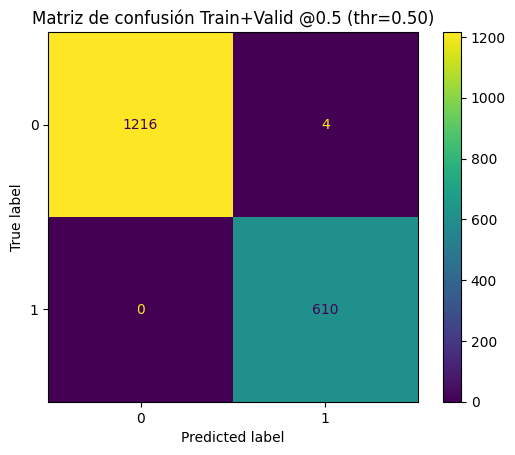

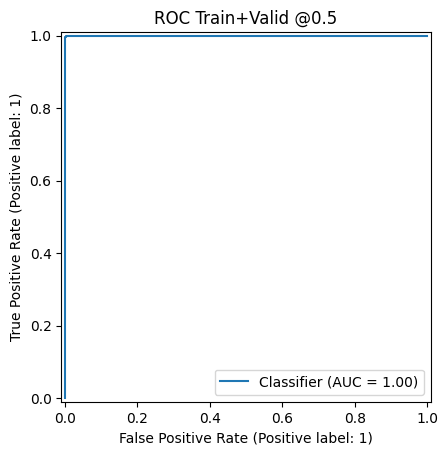

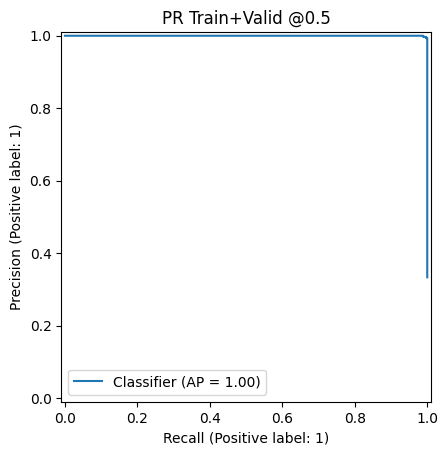

Train+Valid @thr_opt_cv
Umbral=0.500 | ACC=0.998 | PREC=0.993 | REC=1.000 | F1=0.997 | ROC-AUC=1.000


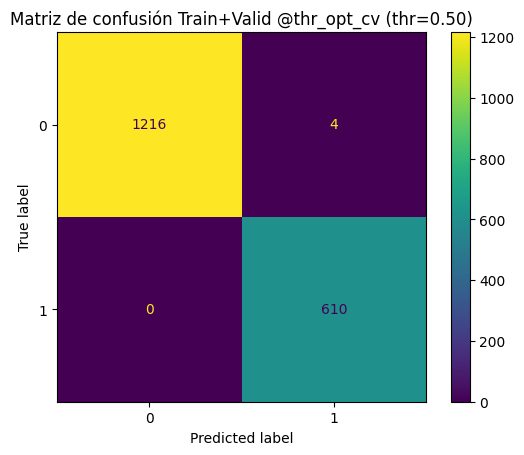

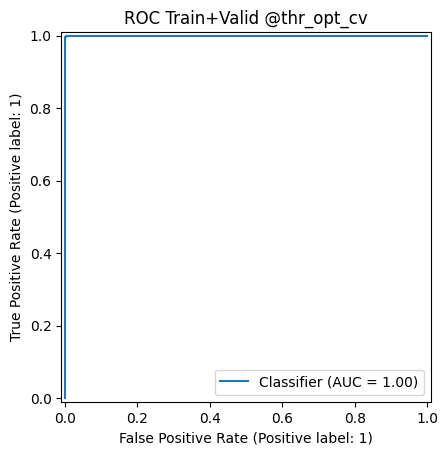

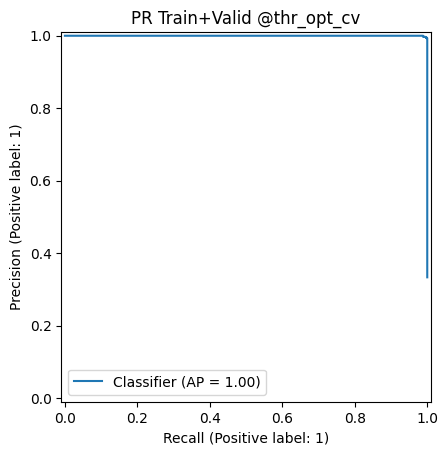


✅ Sección 5 finalizada. Artefactos listos para inferencia/Gradio:
   - Modelo calibrado: /content/artifacts/clf_bin.pkl
   - Umbral sugerido: /content/artifacts/thresholds.json
   - Resultados CV: /content/artifacts/cv_results.csv


In [ ]:
# @title 5) Entrenamiento, tuning, calibración y reporte (binario: riesgo vs no riesgo)
import os, json, numpy as np, pandas as pd, joblib, warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Paths de artefactos
ARTIFACTS_DIR = "/content/artifacts"
EMB_NPY = os.path.join(ARTIFACTS_DIR, "embeddings.npy")
DF_PKL  = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")
FOLDS_JSON = os.path.join(ARTIFACTS_DIR, "groupkfold_folds.json")
TEST_JSON  = os.path.join(ARTIFACTS_DIR, "test_idx.json")
MODEL_PKL  = os.path.join(ARTIFACTS_DIR, "clf_bin.pkl")
THRESH_JSON= os.path.join(ARTIFACTS_DIR, "thresholds.json")
CVCSV_PATH = os.path.join(ARTIFACTS_DIR, "cv_results.csv")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# Cargar insumos
if 'embeddings' not in globals():
    embeddings = np.load(EMB_NPY)

if 'df_clean' not in globals():
    df_clean = pd.read_pickle(DF_PKL)

y = df_clean["es_riesgo"].astype(int).values

with open(FOLDS_JSON, "r") as f:
    folds = json.load(f)

with open(TEST_JSON, "r") as f:
    idx_test = json.load(f).get("idx_test", [])

print(f"Embeddings: {embeddings.shape}  |  y: {y.shape}  |  folds: {len(folds)}  |  test_idx: {len(idx_test)}")

# ─────────────────────────────────────────────────────────────────────────────
# 5.b) Búsqueda simple de hiperparámetros (Regresión Logística sobre embeddings)
param_grid = {
    "C": [0.1, 1.0, 3.0, 10.0],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"],
    "max_iter": [2000]
}

def eval_fold(Xtr, ytr, Xva, yva, params, thresholds=None):
    """Entrena un LR, evalúa en valid. Retorna métricas con umbral 0.5 y mejor umbral por F1."""
    clf = LogisticRegression(**params)
    clf.fit(Xtr, ytr)

    p = clf.predict_proba(Xva)[:,1]
    # Métricas con umbral 0.5
    yhat = (p >= 0.5).astype(int)
    acc = accuracy_score(yva, yhat)
    pr, rc, f1, _ = precision_recall_fscore_support(yva, yhat, average="binary", zero_division=0)
    roc = roc_auc_score(yva, p) if len(np.unique(yva))==2 else np.nan

    # Buscar umbral óptimo por F1 (grid simple)
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 19)
    f1s = []
    for t in thresholds:
        yhat_t = (p >= t).astype(int)
        f1_t = precision_recall_fscore_support(yva, yhat_t, average="binary", zero_division=0)[2]
        f1s.append((t, f1_t))
    best_thr, best_f1 = max(f1s, key=lambda z: z[1])

    return {
        "acc": acc, "prec": pr, "rec": rc, "f1": f1, "roc_auc": roc,
        "best_thr": float(best_thr), "best_f1": float(best_f1)
    }, clf, p

# Cross-validation manual con tus folds (o 1 fold si hiciste fallback 80/20)
rows, best_score, best_cfg, best_model = [], -1, None, None
for cfg in ParameterGrid(param_grid):
    fold_metrics = []
    fold_probs = []  # para promediar thresholds
    fold_thrs  = []

    for f in folds:
        tr, va = np.array(f["train_idx"]), np.array(f["valid_idx"])
        Xtr, ytr = embeddings[tr], y[tr]
        Xva, yva = embeddings[va], y[va]

        m, clf, pva = eval_fold(Xtr, ytr, Xva, yva, cfg)
        fold_metrics.append(m)
        fold_probs.append((yva, pva))
        fold_thrs.append(m["best_thr"])

        rows.append({
            "C":cfg["C"], "class_weight":cfg["class_weight"], "solver":cfg["solver"],
            "acc":m["acc"], "prec":m["prec"], "rec":m["rec"], "f1":m["f1"], "roc_auc":m["roc_auc"],
            "best_thr":m["best_thr"], "best_f1":m["best_f1"]
        })

    # Promedios por config
    mean_f1 = float(np.nanmean([m["f1"] for m in fold_metrics])) if fold_metrics else 0.0
    mean_best_f1 = float(np.nanmean([m["best_f1"] for m in fold_metrics])) if fold_metrics else 0.0
    mean_thr = float(np.nanmean(fold_thrs)) if fold_thrs else 0.5

    if mean_f1 > best_score:
        best_score = mean_f1
        best_cfg   = cfg
        best_model = clf   # último entrenado (luego reentrenamos full)
        best_thr_cv = mean_thr
        best_f1_cv  = mean_best_f1

cv_df = pd.DataFrame(rows)
cv_df.to_csv(CVCSV_PATH, index=False)
print("▶︎ CV finalizada. Guardado resumen:", CVCSV_PATH)
print("Mejor config (por F1-valid promedio @0.5):", best_cfg, "| F1 =", round(best_score, 3))
print("Umbral medio sugerido por CV (F1-opt):", round(best_thr_cv, 3), "| F1@thr ≈", round(best_f1_cv, 3))

# ─────────────────────────────────────────────────────────────────────────────
# 5.c) Reentrenar modelo en todo el train+valid (excluye holdout si existe)
if idx_test:
    mask = np.ones(len(y), dtype=bool); mask[idx_test] = False
    X_train_full, y_train_full = embeddings[mask], y[mask]
else:
    X_train_full, y_train_full = embeddings, y

base_clf = LogisticRegression(**best_cfg).fit(X_train_full, y_train_full)

# Calibración de probabilidades (sigmoid). Compatible con sklearn >=1.4 y <1.4
try:
    cal_clf = CalibratedClassifierCV(estimator=base_clf, method="sigmoid", cv=3)
except TypeError:
    cal_clf = CalibratedClassifierCV(base_estimator=base_clf, method="sigmoid", cv=3)

cal_clf.fit(X_train_full, y_train_full)

# Guardar modelo y umbral óptimo sugerido por CV
joblib.dump(cal_clf, MODEL_PKL)
with open(THRESH_JSON, "w") as f:
    json.dump({"thr_opt_cv": float(best_thr_cv)}, f, indent=2)
print("🧩 Modelo calibrado guardado en:", MODEL_PKL)
print("🧩 Umbral sugerido guardado en:", THRESH_JSON)

# ─────────────────────────────────────────────────────────────────────────────
# 6) Reporte de métricas (holdout test si existe; si no, train+valid orientativo)
def report_metrics(y_true, y_prob, title="", thr=0.5):
    yhat = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, yhat)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, yhat, average="binary", zero_division=0)
    roc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))==2 else np.nan
    print(f"{title}\nUmbral={thr:.3f} | ACC={acc:.3f} | PREC={pr:.3f} | REC={rc:.3f} | F1={f1:.3f} | ROC-AUC={roc:.3f}")
    ConfusionMatrixDisplay.from_predictions(y_true, yhat)
    plt.title(f"Matriz de confusión {title} (thr={thr:.2f})"); plt.show()
    RocCurveDisplay.from_predictions(y_true, y_prob)
    plt.title(f"ROC {title}"); plt.show()
    PrecisionRecallDisplay.from_predictions(y_true, y_prob)
    plt.title(f"PR {title}"); plt.show()

if idx_test:
    p_test = cal_clf.predict_proba(embeddings[idx_test])[:,1]
    # Reporte a 0.5
    report_metrics(y[idx_test], p_test, title="Holdout TEST @0.5", thr=0.5)
    # Reporte con umbral óptimo por CV
    report_metrics(y[idx_test], p_test, title="Holdout TEST @thr_opt_cv", thr=best_thr_cv)
else:
    print("ℹ️ No hay holdout por documento. Reporte sobre Train+Valid (orientativo).")
    p_all = cal_clf.predict_proba(embeddings)[:,1]
    report_metrics(y, p_all, title="Train+Valid @0.5", thr=0.5)
    report_metrics(y, p_all, title="Train+Valid @thr_opt_cv", thr=best_thr_cv)

print("\n✅ Sección 5 finalizada. Artefactos listos para inferencia/Gradio:")
print("   - Modelo calibrado:", MODEL_PKL)
print("   - Umbral sugerido:", THRESH_JSON)
print("   - Resultados CV:", CVCSV_PATH)


In [ ]:
# @title 6) Evaluación y explicación (carga robusta de artefactos)
import os, json, numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay
from sentence_transformers import SentenceTransformer

ARTIFACTS_DIR = "/content/artifacts"
EMB_NPY   = os.path.join(ARTIFACTS_DIR, "embeddings.npy")
DF_PKL    = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")
DF_XLSX_2 = os.path.join(ARTIFACTS_DIR, "dataset_etiquetado_clean.xlsx")
DF_XLSX_1 = "dataset_etiquetado_clean.xlsx"  # por si quedó en raíz
MODEL_PKL = os.path.join(ARTIFACTS_DIR, "clf_bin.pkl")
THR_JSON  = os.path.join(ARTIFACTS_DIR, "thresholds.json")
FOLDS_JSON= os.path.join(ARTIFACTS_DIR, "groupkfold_folds.json")
TEST_JSON = os.path.join(ARTIFACTS_DIR, "test_idx.json")
IDMAP_JSON= os.path.join(ARTIFACTS_DIR, "id_map.json")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 1) Embeddings (requerido)
embeddings = np.load(EMB_NPY)

# 2) Dataset limpio: intenta varias fuentes
def _normalize_cols(df):
    # normaliza a minúsculas y nombres esperados
    rename = {
        "ID":"id","Texto":"texto","Es_riesgo":"es_riesgo",
        "L1_Codigo":"l1_codigo","L1_Nombre":"l1_nombre",
        "L2_Codigo":"l2_codigo","L2_Nombre":"l2_nombre",
        "Fase_sugerida":"fase_sugerida","Impacto_dom":"impacto_dom",
        "Notas":"notas","Doc_ID":"doc_id","Página":"pagina",
        "Sección":"seccion","Fuente":"fuente"
    }
    for c in list(df.columns):
        if c in rename: df.rename(columns={c:rename[c]}, inplace=True)
    # asegura columnas mínimas
    must = ["id","texto","es_riesgo"]
    for c in must:
        if c not in df.columns:
            raise ValueError(f"Falta columna requerida '{c}' en el DataFrame reconstruido.")
    return df

df = None
if os.path.exists(DF_PKL):
    df = pd.read_pickle(DF_PKL)
    print("✅ df_clean cargado desde:", DF_PKL)
elif os.path.exists(DF_XLSX_2):
    df = pd.read_excel(DF_XLSX_2)
    df = _normalize_cols(df)
    print("✅ df_clean reconstruido desde Excel:", DF_XLSX_2)
elif os.path.exists(DF_XLSX_1):
    df = pd.read_excel(DF_XLSX_1)
    df = _normalize_cols(df)
    print("✅ df_clean reconstruido desde Excel:", DF_XLSX_1)
elif os.path.exists(IDMAP_JSON):
    # 3) Reconstrucción mínima desde id_map.json (Sección 3)
    with open(IDMAP_JSON, "r", encoding="utf-8") as f:
        id_map = json.load(f)
    df = pd.DataFrame({
        "id":        id_map.get("id", []),
        "texto":     id_map.get("texto", []),
        "es_riesgo": id_map.get("es_riesgo", []),
        "l1_codigo": id_map.get("l1_codigo", []),
        "l2_codigo": id_map.get("l2_codigo", []),
        "doc_id":    id_map.get("doc_id", []),
    })
    # tipificación mínima
    if "es_riesgo" in df.columns:
        df["es_riesgo"] = pd.to_numeric(df["es_riesgo"], errors="coerce").fillna(0).astype(int)
    print("✅ df_clean reconstruido mínimamente desde id_map.json")
else:
    raise FileNotFoundError(
        "No se encontró df_clean.pkl ni Excel limpio ni id_map.json. "
        "Vuelve a ejecutar la Sección 2 (limpieza) o la Sección 3 (id_map)."
    )

# 4) Variables objetivo y modelo calibrado
y = df["es_riesgo"].astype(int).values
cal_clf = joblib.load(MODEL_PKL)

with open(THR_JSON, "r") as f:
    thr_opt = json.load(f).get("thr_opt_cv", 0.5)

with open(TEST_JSON, "r") as f:
    idx_test = json.load(f).get("idx_test", [])

# 5) Cargar encoder para explicabilidad por similitud
if os.path.exists(IDMAP_JSON):
    with open(IDMAP_JSON, "r", encoding="utf-8") as f:
        id_map = json.load(f)
    model_name = id_map.get("model_name", "distiluse-base-multilingual-cased-v2")
else:
    model_name = "distiluse-base-multilingual-cased-v2"
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer(model_name)

print(f"Embeddings: {embeddings.shape} | y: {y.shape} | test_idx: {len(idx_test)} | umbral_cv: {thr_opt:.2f}")


✅ df_clean cargado desde: /content/artifacts/df_clean.pkl
Embeddings: (1830, 512) | y: (1830,) | test_idx: 0 | umbral_cv: 0.50


In [ ]:
# @title 7.Alt) PDF → posibles riesgos (versión Gradio)

import os, io, re, json, time
import numpy as np
import pandas as pd

from pdfminer.high_level import extract_text
from sentence_transformers import SentenceTransformer
import gradio as gr

# ─────────────────────────────────────────────────────────────────────────────
# Artefactos esperados (generados en secciones previas)
ARTIFACTS_DIR = "/content/artifacts"
IDMAP_JSON = os.path.join(ARTIFACTS_DIR, "id_map.json")          # de la Sección 3
DF_PKL     = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")        # dataset limpio (opcional)
SYN_PATH   = os.path.join(ARTIFACTS_DIR, "synonyms_rules.json") # de la Sección 2.5

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 0) Cargar id_map (texto, etiquetas, etc.) y encoder SBERT
if not os.path.exists(IDMAP_JSON):
    raise FileNotFoundError("No se encontró id_map.json. Ejecuta la Sección 3 antes de usar 7.ALT.")

with open(IDMAP_JSON, "r", encoding="utf-8") as f:
    id_map = json.load(f)

texts_all  = id_map.get("texto", [])
labels_all = id_map.get("es_riesgo", [])
model_name = id_map.get("model_name", "distiluse-base-multilingual-cased-v2")

sbert = SentenceTransformer(model_name)
print(f"✅ Encoder cargado: {model_name} | oraciones base: {len(texts_all)}")

# ─────────────────────────────────────────────────────────────────────────────
# 1) Normalizador de sinónimos (mismas reglas de la Sección 2.5)
def normalize_with_synonyms(text: str) -> str:
    return text

if os.path.exists(SYN_PATH):
    print("📚 Cargando diccionario técnico:", SYN_PATH)
    with open(SYN_PATH, "r", encoding="utf-8") as f:
        syn = json.load(f)
    compiled_rules = [(re.compile(pat), can) for (pat, can) in syn.get("rules", [])]

    def normalize_with_synonyms(text: str) -> str:
        t = text
        for rx, can in compiled_rules:
            t = rx.sub(can, t)
        return re.sub(r'\s{2,}', ' ', t).strip()

# ─────────────────────────────────────────────────────────────────────────────
# 2) Construir CORPUS de referencia: SOLO RIESGOS (Es_riesgo=1), normalizados
if labels_all and len(labels_all) == len(texts_all):
    mask_pos = [int(x) == 1 for x in labels_all]
    risk_texts_raw = [t for t, m in zip(texts_all, mask_pos) if m]
else:
    if os.path.exists(DF_PKL):
        dfc = pd.read_pickle(DF_PKL)
        risk_texts_raw = dfc.loc[dfc["es_riesgo"].astype(int)==1, "texto"].astype(str).tolist()
    else:
        raise ValueError("No hay etiquetas en id_map y no se encontró df_clean.pkl para construir el corpus de riesgo.")

if len(risk_texts_raw) == 0:
    raise ValueError("Tu base no tiene frases etiquetadas como riesgo (Es_riesgo=1).")

# Aplica sinónimos al corpus de referencia
risk_texts = [normalize_with_synonyms(t) for t in risk_texts_raw]
print(f"📌 Frases de referencia (riesgo=1): {len(risk_texts)}")

# Embeddings del corpus de riesgo (normalizados)
emb_risk = sbert.encode(
    risk_texts,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

# ─────────────────────────────────────────────────────────────────────────────
# 3) Tokenizador de oraciones (sencillo y robusto para ES/EN técnico)
_SENT_SPLIT_RE = re.compile(
    r'(?<!\b[A-Z]\.)(?<!\bSr\.)(?<!\bSra\.)(?<!\bDr\.)(?<!\bDra\.)'
    r'(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÑ])'
)

def sent_tokenize_simple(text: str):
    text = re.sub(r'\s+', ' ', text).strip()
    parts = re.split(_SENT_SPLIT_RE, text)
    sents = [s.strip() for s in parts if len(s.strip()) >= 20]
    seen = set()
    out = []
    for s in sents:
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out

# ─────────────────────────────────────────────────────────────────────────────
# 4) Función principal para Gradio
def analizar_pdf_gradio(pdf_file, sim_min=0.50, top_n=200):
    """
    Recibe un PDF, extrae oraciones, calcula similitud contra la base de riesgos (Es_riesgo=1)
    y devuelve:
      - Archivo Excel con:
           Hoja 'Oraciones' (vertical)
           Hoja 'Detalle'   (oración, similitud, riesgo de referencia)
      - DataFrame de detalle para previsualización en la UI.
    """
    if pdf_file is None:
        return None, pd.DataFrame(columns=["Posible_Riesgo", "Similitud_max", "Riesgo_ref"])

    fname = pdf_file.name
    if not fname.lower().endswith(".pdf"):
        raise ValueError("El archivo debe ser un PDF (.pdf).")

    # 4.1 Extraer texto del PDF
    pdf_text = extract_text(fname)
    if not pdf_text or len(pdf_text.strip()) == 0:
        raise ValueError("No se pudo extraer texto útil del PDF (¿estará escaneado sin OCR?).")

    # 4.2 Tokenizar a oraciones y normalizar con sinónimos
    pdf_sents_raw = sent_tokenize_simple(pdf_text)
    if len(pdf_sents_raw) == 0:
        raise ValueError("No se encontraron oraciones lo suficientemente largas en el PDF.")
    pdf_sents_norm = [normalize_with_synonyms(s) for s in pdf_sents_raw]

    # 4.3 Embeddings de las oraciones del PDF y similitud con corpus de riesgo
    emb_pdf = sbert.encode(
        pdf_sents_norm,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    S = emb_pdf @ emb_risk.T  # producto punto = coseno (normalizados)
    max_sim   = S.max(axis=1)
    argmax_ix = S.argmax(axis=1)

    # 4.4 Filtrar por umbral de similitud y top-N
    sim_min = float(sim_min)
    top_n   = int(top_n)

    idx_sel = np.where(max_sim >= sim_min)[0]
    if len(idx_sel) == 0:
        # si ninguna supera el umbral, devolver top-N global
        idx_sel = np.argsort(-max_sim)[:min(top_n, len(max_sim))]
    else:
        idx_sel = idx_sel[np.argsort(-max_sim[idx_sel])]
        idx_sel = idx_sel[:min(top_n, len(idx_sel))]

    # 4.5 DataFrame de detalle
    df_out = pd.DataFrame({
        "Posible_Riesgo":       [pdf_sents_raw[i] for i in idx_sel],
        "Posible_Riesgo_norm":  [pdf_sents_norm[i] for i in idx_sel],
        "Similitud_max":        [float(max_sim[i]) for i in idx_sel],
        "Riesgo_ref":           [risk_texts[int(argmax_ix[i])] for i in idx_sel]
    })

    # 4.6 Excel VERTICAL: una sola hoja simple para pegar en matrices
    df_vertical = pd.DataFrame({"Posible_Riesgo": df_out["Posible_Riesgo"]})

    ts = time.strftime("%Y%m%d_%H%M%S")
    out_xlsx = f"/content/extract_riesgos_pdf_VERTICAL_{ts}.xlsx"
    with pd.ExcelWriter(out_xlsx) as writer:
        df_vertical.to_excel(writer, sheet_name="Oraciones", index=False)
        df_out.to_excel(writer, sheet_name="Detalle", index=False)

    # Gradio devolverá:
    #  - el archivo para descarga
    #  - el dataframe de detalle para ver en pantalla
    return out_xlsx, df_out

# ─────────────────────────────────────────────────────────────────────────────
# 5) Interfaz Gradio
demo_pdf = gr.Interface(
    fn=analizar_pdf_gradio,
    inputs=[
        gr.File(label="PDF a analizar", file_types=[".pdf"]),
        gr.Slider(0.3, 0.9, value=0.50, step=0.01, label="Umbral mínimo de similitud (SIM_MIN)"),
        gr.Slider(20, 500, value=200, step=10, label="Máximo de oraciones a exportar (TOP_N)")
    ],
    outputs=[
        gr.File(label="Descargar Excel con resultados"),
        gr.Dataframe(label="Detalle de oraciones detectadas")
    ],
    title="Detector de posibles riesgos en PDF (basado en riesgos conocidos)",
    description=(
        "Sube un PDF (no escaneado) y el sistema buscará oraciones similares a los riesgos ya etiquetados "
        "en tu base (Es_riesgo=1), usando embeddings SBERT y similitud de coseno."
    )
)

demo_pdf.launch()


✅ Encoder cargado: distiluse-base-multilingual-cased-v2 | oraciones base: 1830
📚 Cargando diccionario técnico: /content/artifacts/synonyms_rules.json
📌 Frases de referencia (riesgo=1): 610
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d9d90eeb837e839a46.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# @title 7) Sup App Gradio – Análisis de PDF (clasificador + similitud)

import os, io, re, json, time
import numpy as np
import pandas as pd
from pdfminer.high_level import extract_text
from sentence_transformers import SentenceTransformer
import joblib
import gradio as gr

ARTIFACTS_DIR = "/content/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

MODEL_PKL  = os.path.join(ARTIFACTS_DIR, "clf_bin.pkl")
THR_JSON   = os.path.join(ARTIFACTS_DIR, "thresholds.json")
IDMAP_JSON = os.path.join(ARTIFACTS_DIR, "id_map.json")
SYN_PATH   = os.path.join(ARTIFACTS_DIR, "synonyms_rules.json")
DF_PKL     = os.path.join(ARTIFACTS_DIR, "df_clean.pkl")

# ─────────────────────────────────────────────────────────────────────────────
# 1) Cargar modelo calibrado, umbral y artefactos base

if not os.path.exists(MODEL_PKL):
    raise FileNotFoundError("No se encontró clf_bin.pkl. Ejecuta la Sección 5 (entrenamiento).")

if not os.path.exists(THR_JSON):
    raise FileNotFoundError("No se encontró thresholds.json. Ejecuta la Sección 5 (entrenamiento).")

if not os.path.exists(IDMAP_JSON):
    raise FileNotFoundError("No se encontró id_map.json. Ejecuta la Sección 3 (id_map).")

cal_clf = joblib.load(MODEL_PKL)

with open(THR_JSON, "r") as f:
    thr_opt = float(json.load(f).get("thr_opt_cv", 0.5))

with open(IDMAP_JSON, "r", encoding="utf-8") as f:
    id_map = json.load(f)

texts_all  = id_map.get("texto", [])
labels_all = id_map.get("es_riesgo", [])
model_name = id_map.get("model_name", "distiluse-base-multilingual-cased-v2")

sbert = SentenceTransformer(model_name)
print(f"✅ Encoder cargado: {model_name} | oraciones base:", len(texts_all))

# ─────────────────────────────────────────────────────────────────────────────
# 2) Normalizador de sinónimos (mismas reglas que en 2.5)

def normalize_with_synonyms(text: str) -> str:
    return text

if os.path.exists(SYN_PATH):
    print("📚 Cargando diccionario técnico:", SYN_PATH)
    with open(SYN_PATH, "r", encoding="utf-8") as f:
        syn = json.load(f)
    compiled_rules = [(re.compile(pat), can) for (pat, can) in syn.get("rules", [])]

    def normalize_with_synonyms(text: str) -> str:
        t = text or ""
        for rx, can in compiled_rules:
            t = rx.sub(can, t)
        return re.sub(r"\s{2,}", " ", t).strip()

# ─────────────────────────────────────────────────────────────────────────────
# 3) Construir CORPUS de referencia: SOLO RIESGOS (Es_riesgo=1)

if labels_all and len(labels_all) == len(texts_all):
    mask_pos = [int(x) == 1 for x in labels_all]
    risk_texts_raw = [t for t, m in zip(texts_all, mask_pos) if m]
else:
    if os.path.exists(DF_PKL):
        dfc = pd.read_pickle(DF_PKL)
        risk_texts_raw = dfc.loc[dfc["es_riesgo"].astype(int) == 1, "texto"].astype(str).tolist()
    else:
        raise ValueError("No hay etiquetas en id_map y no se encontró df_clean.pkl para el corpus de riesgo.")

if len(risk_texts_raw) == 0:
    raise ValueError("Tu base no tiene frases etiquetadas como riesgo (Es_riesgo=1).")

risk_texts = [normalize_with_synonyms(t) for t in risk_texts_raw]

emb_risk = sbert.encode(
    risk_texts,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

print(f"📌 Frases de referencia (riesgo=1): {len(risk_texts)}")

# ─────────────────────────────────────────────────────────────────────────────
# 4) Tokenizador de oraciones

_SENT_SPLIT_RE = re.compile(
    r'(?<!\b[A-Z]\.)(?<!\bSr\.)(?<!\bSra\.)(?<!\bDr\.)(?<!\bDra\.)'
    r'(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÑ])'
)

def sent_tokenize_simple(text: str):
    text = re.sub(r'\s+', ' ', text).strip()
    parts = re.split(_SENT_SPLIT_RE, text)
    sents = [s.strip() for s in parts if len(s.strip()) >= 20]
    seen = set()
    out = []
    for s in sents:
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out

# ─────────────────────────────────────────────────────────────────────────────
# 4.b) Clasificador simple de tipo de oración (núcleo / impacto / metodológico)

# Patrones de "núcleo de riesgo"
_CORE_PATTERNS = [
    r"\bexiste el riesgo de\b",
    r"\briesgo de que\b",
    r"\briesgo de\b",
    r"\bposibilidad de que\b",
    r"\bprobabilidad de que\b",
    r"\bpuede ocurrir que\b",
    r"\bpodría ocurrir que\b",
]

# Patrones típicos de impacto / consecuencia (no un riesgo nuevo)
_IMPACT_PATTERNS = [
    r"\beste riesgo\b.*\bpuede\b.*\bderivar\b",
    r"\beste riesgo\b.*\bpuede\b.*\btraducirse\b",
    r"\bmala gestión de este riesgo\b",
    r"\bpuede derivar en\b",
    r"\bpuede traducirse en\b",
]

# Patrones metodológicos / de marco (no describen un evento riesgoso específico)
_METODO_PATTERNS = [
    r"\bidentificación y gestión de riesgos\b",
    r"\bgestión de riesgos se convierte\b",
    r"\bmarco de gestión de riesgos\b",
    r"\bcomponente central del expediente técnico\b",
]

def classify_sentence_role(text: str) -> str:
    """
    Clasifica la oración en:
      - 'nucleo'        -> formula explícitamente un riesgo
      - 'asociado'     -> habla del riesgo, pero como impacto / contexto
      - 'metodologico' -> enunciado de marco / gestión, no riesgo específico
      - 'otro'         -> sin patrones claros de riesgo
    """
    if not text:
        return "otro"

    t = text.lower()

    # 1) Metodológico (falsos positivos típicos)
    for pat in _METODO_PATTERNS:
        if re.search(pat, t):
            return "metodologico"

    # 2) Núcleo de riesgo (estructura causa–riesgo–efecto típica)
    for pat in _CORE_PATTERNS:
        if re.search(pat, t):
            return "nucleo"

    # 3) Impacto / consecuencia asociada al riesgo
    for pat in _IMPACT_PATTERNS:
        if re.search(pat, t):
            return "asociado"

    # 4) Si menciona "riesgo" pero sin patrón claro, lo marcamos como asociado
    if "riesgo" in t or "riesgos" in t:
        return "asociado"

    return "otro"

# ─────────────────────────────────────────────────────────────────────────────
# 5) Función principal para Gradio (probabilidad + similitud)

def analizar_pdf_clf_gradio(pdf_file, thr_prob=0.50, sim_min=0.50, top_n=200):
    """
    - Extrae oraciones del PDF.
    - Calcula probabilidad de riesgo con el modelo binario.
    - Calcula similitud coseno contra el corpus de riesgos (Es_riesgo=1).
    - Filtra por:
        prob >= thr_prob  OR  similitud >= sim_min.
    - Aplica un filtro adicional:
        descarta oraciones metodológicas (Tipo_oracion='metodologico').
    - Devuelve Excel + DataFrame de detalle.
    """
    if pdf_file is None:
        return None, pd.DataFrame(columns=["Texto","Prob_Riesgo","Similitud_max","Riesgo_ref","Tipo_oracion"])

    fname = pdf_file.name
    if not fname.lower().endswith(".pdf"):
        raise ValueError("El archivo debe ser un PDF (.pdf).")

    # 5.1 Extraer texto
    pdf_text = extract_text(fname)
    if not pdf_text or len(pdf_text.strip()) == 0:
        raise ValueError("No se pudo extraer texto útil del PDF (¿estará escaneado sin OCR?).")

    # 5.2 Oraciones y normalización
    pdf_sents_raw = sent_tokenize_simple(pdf_text)
    if len(pdf_sents_raw) == 0:
        raise ValueError("No se encontraron oraciones lo suficientemente largas en el PDF.")

    pdf_sents_norm = [normalize_with_synonyms(s) for s in pdf_sents_raw]

    # 5.3 Embeddings + probabilidad de riesgo
    emb_pdf = sbert.encode(
        pdf_sents_norm,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    probas = cal_clf.predict_proba(emb_pdf)[:, 1]  # (N,)

    # 5.4 Similitud con corpus de riesgo
    S = emb_pdf @ emb_risk.T
    max_sim   = S.max(axis=1)
    argmax_ix = S.argmax(axis=1)

    thr_prob = float(thr_prob)
    sim_min  = float(sim_min)
    top_n    = int(top_n)

    # 5.5 Selección de oraciones (modelo + similitud)
    mask_sel = (probas >= thr_prob)
    if sim_min > 0:
        mask_sel = mask_sel | (max_sim >= sim_min)

    idx_sel = np.where(mask_sel)[0]
    if len(idx_sel) == 0:
        # si nada cumple, devolver top-N por probabilidad
        idx_sel = np.argsort(-probas)[:min(top_n, len(probas))]
    else:
        # ordenar primero por probabilidad, luego recortar
        idx_sel = idx_sel[np.argsort(-probas[idx_sel])]
        idx_sel = idx_sel[:min(top_n, len(idx_sel))]

    # 5.5.b Clasificar tipo de oración y filtrar metodológicas
    roles = [classify_sentence_role(pdf_sents_raw[i]) for i in idx_sel]

    idx_filtrados = [i for i, r in zip(idx_sel, roles) if r != "metodologico"]
    roles_filtrados = [r for r in roles if r != "metodologico"]

    # Si todos eran metodológicos, mantenemos los originales (para no devolver vacío)
    if len(idx_filtrados) > 0:
        idx_sel = np.array(idx_filtrados, dtype=int)
        roles = roles_filtrados
    else:
        # Recalcular roles sobre idx_sel original
        roles = [classify_sentence_role(pdf_sents_raw[i]) for i in idx_sel]

    # 5.6 DataFrame de salida
    df_out = pd.DataFrame({
        "Texto":         [pdf_sents_raw[i] for i in idx_sel],
        "Texto_norm":    [pdf_sents_norm[i] for i in idx_sel],
        "Prob_Riesgo":   [float(probas[i]) for i in idx_sel],
        "Similitud_max": [float(max_sim[i]) for i in idx_sel],
        "Riesgo_ref":    [risk_texts[int(argmax_ix[i])] for i in idx_sel],
        "Tipo_oracion":  roles
    })

    # Vista "vertical" simple para pegar en matrices (sólo el texto original)
    df_vertical = pd.DataFrame({"Posible_Riesgo": df_out["Texto"]})

    ts = time.strftime("%Y%m%d_%H%M%S")
    out_xlsx = f"/content/analisis_riesgos_pdf_{ts}.xlsx"
    with pd.ExcelWriter(out_xlsx) as writer:
        df_vertical.to_excel(writer, sheet_name="Oraciones", index=False)
        df_out.to_excel(writer, sheet_name="Detalle", index=False)

    return out_xlsx, df_out

# ─────────────────────────────────────────────────────────────────────────────
# 6) Interfaz Gradio

demo_pdf_clf = gr.Interface(
    fn=analizar_pdf_clf_gradio,
    inputs=[
        gr.File(label="PDF a analizar", file_types=[".pdf"]),
        gr.Slider(0.0, 1.0, value=float(thr_opt), step=0.01,
                  label="Umbral mínimo de probabilidad de riesgo"),
        gr.Slider(0.3, 0.9, value=0.50, step=0.01,
                  label="Umbral mínimo de similitud (opcional)"),
        gr.Slider(20, 500, value=200, step=10,
                  label="Máximo de oraciones a exportar (TOP_N)")
    ],
    outputs=[
        gr.File(label="Descargar Excel con resultados"),
        gr.Dataframe(label="Detalle de oraciones detectadas")
    ],
    title="Análisis de PDF – Detección de riesgos (modelo + similitud)",
    description=(
        "Sube un PDF (no escaneado) y el sistema evaluará cada oración con el modelo binario de riesgos, "
        "además de comparar contra tu corpus de riesgos conocidos (Es_riesgo=1). "
        "Se filtran oraciones metodológicas y se etiqueta el tipo de oración "
        "(núcleo, asociado, metodológico, otro). "
        "Puedes filtrar por probabilidad y/o similitud, y descargar un Excel con los resultados."
    )
)

demo_pdf_clf.launch()


✅ Encoder cargado: distiluse-base-multilingual-cased-v2 | oraciones base: 1830
📚 Cargando diccionario técnico: /content/artifacts/synonyms_rules.json
📌 Frases de referencia (riesgo=1): 610
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a4084a16a2a3e2cab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# @title Subir `Guia_PlanRespuesta.xlsx` al entorno de trabajo

from google.colab import files
import os

print("📥 Sube tu archivo de guía de planes de respuesta (idealmente 'Guia_PlanRespuesta.xlsx')...")
uploaded = files.upload()

if not uploaded:
    raise SystemExit("No se subió ningún archivo.")

# Tomamos el primer archivo subido
orig_name = list(uploaded.keys())[0]

# Si el nombre es distinto, lo renombramos a 'Guia_PlanRespuesta.xlsx'
target_name = "Guia_PlanRespuesta.xlsx"
if orig_name != target_name:
    if os.path.exists(target_name):
        os.remove(target_name)
    os.rename(orig_name, target_name)

print(f"✅ Archivo disponible como: {target_name}")


📥 Sube tu archivo de guía de planes de respuesta (idealmente 'Guia_PlanRespuesta.xlsx')...


Saving Guia_PlanRespuesta.xlsx to Guia_PlanRespuesta (1).xlsx
✅ Archivo disponible como: Guia_PlanRespuesta.xlsx


In [ ]:
# @title 10) Cargar Dataset/Guía y sugerir acciones de respuesta (lee hoja 'Detalle')

# Se asume que ya tienes importado:
#   import pandas as pd
#   from rapidfuzz import process as rf_process

import re
from google.colab import files

# -------------------------------------------------------------------
# 1. Helpers de normalización de nombres de columna
# -------------------------------------------------------------------
def _norm_colname(c):
    c = str(c).strip().lower()
    c = (c.replace("á", "a").replace("é", "e").replace("í", "i")
           .replace("ó", "o").replace("ú", "u").replace("ñ", "n"))
    c = re.sub(r"[^a-z0-9_]+", "_", c)
    return c

def _build_colmap(df, role_to_candidates):
    """
    role_to_candidates: dict {rol: [lista de posibles nombres normalizados]}
    Retorna dict {rol: nombre_real_en_df}
    """
    norm = {_norm_colname(c): c for c in df.columns}
    out = {}
    for role, cands in role_to_candidates.items():
        for cand in cands:
            if cand in norm:
                out[role] = norm[cand]
                break
    return out

# -------------------------------------------------------------------
# 2. Cargar Dataset base (Riesgo_ref -> L1/L2)
# -------------------------------------------------------------------
# Asegúrate de tener "Dataset.xlsx" en el directorio de trabajo
df_base = pd.read_excel("Dataset.xlsx")

base_colmap = _build_colmap(
    df_base,
    {
        "texto":      ["texto", "texto_norm", "riesgo_ref", "frase", "oracion", "descripcion"],
        "l1_codigo":  ["l1_codigo", "categoria_rbs", "categoria", "macro"],
        "l1_nombre":  ["l1_nombre", "nombre_l1"],
        "l2_codigo":  ["l2_codigo", "subcategoria_rbs", "subcategoria", "detalle"],
        "l2_nombre":  ["l2_nombre", "nombre_l2"],
    }
)

if "texto" not in base_colmap:
    raise ValueError(
        "En 'Dataset.xlsx' no se encontró una columna tipo texto "
        "(ej. 'Texto', 'Texto_norm' o 'Riesgo_ref')."
    )

# Lista de textos base para el matching rápido
base_texts = df_base[base_colmap["texto"]].astype(str).tolist()

# -------------------------------------------------------------------
# 3. Cargar Guía de planes de respuesta
# -------------------------------------------------------------------
# Asegúrate de tener "Guia_PlanRespuesta.xlsx" en el directorio de trabajo
df_guia = pd.read_excel("Guia_PlanRespuesta.xlsx")

guia_colmap = _build_colmap(
    df_guia,
    {
        "l1_codigo": ["l1_codigo", "categoria_rbs", "categoria", "macro"],
        "l2_codigo": ["l2_codigo", "subcategoria_rbs", "subcategoria", "detalle"],
        "accion":    ["accion_propuesta_al_riesgo", "accion_propuesta", "accion", "accion_riesgo"]
    }
)

if "accion" not in guia_colmap:
    raise ValueError(
        "En 'Guia_PlanRespuesta.xlsx' no se encontró una columna de acción "
        "(ej. 'Accion_propuesta_al_riesgo')."
    )

# -------------------------------------------------------------------
# 4. Funciones de búsqueda
# -------------------------------------------------------------------
def _buscar_l1_l2_desde_riesgoref(riesgo_ref_text, score_cutoff=80):
    """
    Dado un texto Riesgo_ref (del archivo de RESULTADOS),
    busca en Dataset.xlsx la fila más similar y devuelve:
    (l1_codigo, l1_nombre, l2_codigo, l2_nombre, score_match).
    """
    if not isinstance(riesgo_ref_text, str) or not riesgo_ref_text.strip():
        return "", "", "", "", 0.0

    match = rf_process.extractOne(
        riesgo_ref_text,
        base_texts,
        score_cutoff=score_cutoff
    )
    if match is None:
        return "", "", "", "", 0.0

    _, score, idx = match
    row = df_base.iloc[idx]

    l1c = row.get(base_colmap.get("l1_codigo", ""), "")
    l1n = row.get(base_colmap.get("l1_nombre", ""), "")
    l2c = row.get(base_colmap.get("l2_codigo", ""), "")
    l2n = row.get(base_colmap.get("l2_nombre", ""), "")

    return str(l1c), str(l1n), str(l2c), str(l2n), float(score)

def _buscar_accion_en_guia(l1_codigo, l2_codigo):
    """
    Busca en Guia_PlanRespuesta.xlsx la acción propuesta para (L1,L2).
    Orden de búsqueda: L1+L2 -> solo L2 -> solo L1.
    """
    if not isinstance(l1_codigo, str):
        l1_codigo = str(l1_codigo or "")
    if not isinstance(l2_codigo, str):
        l2_codigo = str(l2_codigo or "")

    l1_codigo = l1_codigo.strip().upper()
    l2_codigo = l2_codigo.strip().upper()

    col_l1 = guia_colmap.get("l1_codigo", None)
    col_l2 = guia_colmap.get("l2_codigo", None)
    col_acc = guia_colmap["accion"]

    # 1) Match exacto L1 + L2
    if col_l1 and col_l2:
        mask = (df_guia[col_l1].astype(str).str.upper().str.strip() == l1_codigo) & \
               (df_guia[col_l2].astype(str).str.upper().str.strip() == l2_codigo)
        if mask.any():
            return str(df_guia.loc[mask, col_acc].iloc[0])

    # 2) Solo L2
    if col_l2 and l2_codigo:
        mask = df_guia[col_l2].astype(str).str.upper().str.strip() == l2_codigo
        if mask.any():
            return str(df_guia.loc[mask, col_acc].iloc[0])

    # 3) Solo L1
    if col_l1 and l1_codigo:
        mask = df_guia[col_l1].astype(str).str.upper().str.strip() == l1_codigo
        if mask.any():
            return str(df_guia.loc[mask, col_acc].iloc[0])

    return ""

# -------------------------------------------------------------------
# 5. Función principal SIN GRADIO (lee hoja 'Detalle' si existe)
# -------------------------------------------------------------------
def sugerir_acciones_desde_resultados(path_resultados, score_cutoff=75, guardar_en=None):
    """
    path_resultados: ruta al XLSX de RESULTADOS (como los que generas del PDF).
    - Se intentará leer la hoja 'Detalle'. Si no existe, se usa la primera hoja.
    - Debe tener una columna 'Riesgo_ref' o similar:
      ('Riesgoref', 'Riesgo_referencia', 'Referencia_riesgo').

    score_cutoff: umbral de similitud (0–100) para el matching fuzzy.
    guardar_en: si se pasa una ruta (str), guarda el resultado en un Excel.

    Retorna:
        DataFrame con columnas adicionales:
        L1_Codigo, L1_Nombre, L2_Codigo, L2_Nombre,
        Score_match_riesgo_ref, Accion_propuesta_al_riesgo.
    """
    # Abrimos el Excel y elegimos la hoja
    xls = pd.ExcelFile(path_resultados)
    sheets_lower = {s.lower(): s for s in xls.sheet_names}
    sheet_to_use = sheets_lower.get("detalle", xls.sheet_names[0])

    df_res = pd.read_excel(xls, sheet_name=sheet_to_use)

    # Detectar columna Riesgo_ref de forma robusta
    norm_cols = {_norm_colname(c): c for c in df_res.columns}
    riesgo_ref_col = None
    for cand in ["riesgo_ref", "riesgoref", "riesgo_referencia", "referencia_riesgo"]:
        if cand in norm_cols:
            riesgo_ref_col = norm_cols[cand]
            break

    if riesgo_ref_col is None:
        raise ValueError(
            "En la hoja '%s' no se encontró una columna tipo 'Riesgo_ref' "
            "(acepta también nombres como 'Riesgoref', 'Riesgo_referencia')." % sheet_to_use
        )

    l1c_list, l1n_list, l2c_list, l2n_list, score_list, accion_list = [], [], [], [], [], []

    for txt in df_res[riesgo_ref_col].astype(str).fillna(""):
        l1c, l1n, l2c, l2n, score = _buscar_l1_l2_desde_riesgoref(txt, score_cutoff=score_cutoff)
        accion = _buscar_accion_en_guia(l1c, l2c)
        l1c_list.append(l1c)
        l1n_list.append(l1n)
        l2c_list.append(l2c)
        l2n_list.append(l2n)
        score_list.append(score)
        accion_list.append(accion)

    df_res["L1_Codigo"] = l1c_list
    df_res["L1_Nombre"] = l1n_list
    df_res["L2_Codigo"] = l2c_list
    df_res["L2_Nombre"] = l2n_list
    df_res["Score_match_riesgo_ref"] = score_list
    df_res["Accion_propuesta_al_riesgo"] = accion_list

    if guardar_en is not None:
        df_res.to_excel(guardar_en, index=False)

    return df_res

# -------------------------------------------------------------------
# 6. Subir archivo de RESULTADOS, procesar y descargar
# -------------------------------------------------------------------
print("Sube el Excel de RESULTADOS (con hoja 'Detalle' y columna 'Riesgo_ref')...")
uploaded = files.upload()
path_resultados = list(uploaded.keys())[0]

df_final = sugerir_acciones_desde_resultados(
    path_resultados,
    score_cutoff=75,
    guardar_en="resultados_con_acciones.xlsx"
)

print("Primeras filas del resultado:")
try:
    from IPython.display import display
    display(df_final.head())
except ImportError:
    print(df_final.head().to_string())

print("Se ha guardado 'resultados_con_acciones.xlsx'. Puedes descargarlo:")
files.download("resultados_con_acciones.xlsx")


Sube el Excel de RESULTADOS (con hoja 'Detalle' y columna 'Riesgo_ref')...


Saving analisis_riesgos_pdf_20251123_174303.xlsx to analisis_riesgos_pdf_20251123_174303 (1).xlsx
Primeras filas del resultado:


,Texto,Texto_norm,Prob_Riesgo,Similitud_max,Riesgo_ref,Tipo_oracion,L1_Codigo,L1_Nombre,L2_Codigo,L2_Nombre,Score_match_riesgo_ref,Accion_propuesta_al_riesgo
0,"Este riesgo se refiere a la falta de disponibilidad de los terrenos necesarios para la oportunidad requerida en la Fase 03, lo que impediría empezar la construcción y provocaría un efecto directo ...","Este riesgo se refiere a la falta de disponibilidad de los terrenos necesarios para la oportunidad requerida en la Fase 03, lo que impediría empezar la construcción y provocaría un efecto directo ...",0.999304,0.528094,"Debido a retrasos en la fase de diseño, existe el riesgo de postergar el inicio de la construcción, impactando en el plazo contractual global.",asociado,T,Riesgos técnicos,T-11,Interrelación entre fases,100.0,
1,"No obstante, y en línea con la naturaleza de los eventos, el rol y responsabilidades de PROVIAS NACIONAL y demás Entidades Estatales, el traslado de riesgos no puede tener connotaciones infinitas,...","No obstante, y en línea con la naturaleza de los eventos, el rol y responsabilidades de PROVIAS NACIONAL y demás Entidades Estatales, el traslado de riesgos no puede tener connotaciones infinitas,...",0.994577,0.475761,"Por falta de matriz de riesgos contractuales, puede generarse asignación inadecuada de responsabilidades, impactando costos y plazos.",asociado,L,Cuestiones políticas y jurídicas (no medioambientales),L-33,Cuestiones contractuales,100.0,
2,La consideración de las respuestas del mercado es una medida para identificar posibles causas de licitaciones desiertas y mitigar el riesgo asociado.,La consideración de las respuestas del mercado es una medida para identificar posibles causas de licitaciones desiertas y mitigar el riesgo asociado.,0.992004,0.520441,"Debido a comunicación deficiente entre obra y oficina técnica, existe el riesgo de percepciones divergentes del riesgo, provocando respuestas tardías.",asociado,M,Aspectos organizativos,M-39,Percepción del riesgo,100.0,
3,"En caso de que se materialice el riesgo de una licitación desierta o infructuosa, además del riesgo y impacto reputacional del proyecto, será necesario reiniciar el proceso licitatorio.","En caso de que se materialice el riesgo de una licitación desierta o infructuosa, además del riesgo y impacto reputacional del proyecto, será necesario reiniciar el proceso licitatorio.",0.990063,0.540011,"Debido a inconsistencias en los datos de impacto ambiental, existe el riesgo de iniciar un procedimiento sancionador, afectando la reputación del proyecto.",nucleo,E,Ambientales y de salud,E-22,Permisos ambientales,100.0,
4,"Al respecto, se señala que si no se gestiona este riesgo de forma oportuna podría desencadenar otros eventos como la oposición de algunas organizaciones sociales al Proyecto, por falta de claridad...","Al respecto, se señala que si no se gestiona este riesgo de forma oportuna podría desencadenar otros eventos como la oposición de algunas organizaciones sociales al Proyecto, por falta de claridad...",0.989708,0.487472,"Debido a falta de socialización temprana del proyecto, existe el riesgo de oposición vecinal organizada, provocando paralizaciones y reprogramaciones.",nucleo,L,Políticas y jurídicas (no ambientales),L-27,Participación pública/ONG/comunidades,100.0,


Se ha guardado 'resultados_con_acciones.xlsx'. Puedes descargarlo:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title 10) App Gradio – Sugerir acciones de respuesta a riesgos (lee hoja 'Detalle')

import re
import pandas as pd
import gradio as gr
from rapidfuzz import process as rf_process

# -------------------------------------------------------------------
# 1. Helpers de normalización de nombres de columna
# -------------------------------------------------------------------
def _norm_colname(c):
    c = str(c).strip().lower()
    c = (c.replace("á", "a").replace("é", "e").replace("í", "i")
           .replace("ó", "o").replace("ú", "u").replace("ñ", "n"))
    c = re.sub(r"[^a-z0-9_]+", "_", c)
    return c

def _build_colmap(df, role_to_candidates):
    """
    role_to_candidates: dict {rol: [lista de posibles nombres normalizados]}
    Retorna dict {rol: nombre_real_en_df}
    """
    norm = {_norm_colname(c): c for c in df.columns}
    out = {}
    for role, cands in role_to_candidates.items():
        for cand in cands:
            if cand in norm:
                out[role] = norm[cand]
                break
    return out

# -------------------------------------------------------------------
# 2. Cargar Dataset base (Riesgo_ref -> L1/L2)
# -------------------------------------------------------------------
# Asegúrate de tener "Dataset.xlsx" en el directorio de trabajo
df_base = pd.read_excel("Dataset.xlsx")

base_colmap = _build_colmap(
    df_base,
    {
        "texto":      ["texto", "texto_norm", "riesgo_ref", "frase", "oracion", "descripcion"],
        "l1_codigo":  ["l1_codigo", "categoria_rbs", "categoria", "macro"],
        "l1_nombre":  ["l1_nombre", "nombre_l1"],
        "l2_codigo":  ["l2_codigo", "subcategoria_rbs", "subcategoria", "detalle"],
        "l2_nombre":  ["l2_nombre", "nombre_l2"],
    }
)

if "texto" not in base_colmap:
    raise ValueError(
        "En 'Dataset.xlsx' no se encontró una columna tipo texto "
        "(ej. 'Texto', 'Texto_norm' o 'Riesgo_ref')."
    )

# Lista de textos base para el matching rápido
base_texts = df_base[base_colmap["texto"]].astype(str).tolist()

# -------------------------------------------------------------------
# 3. Cargar Guía de planes de respuesta
# -------------------------------------------------------------------
# Asegúrate de tener "Guia_PlanRespuesta.xlsx" en el directorio de trabajo
df_guia = pd.read_excel("Guia_PlanRespuesta.xlsx")

guia_colmap = _build_colmap(
    df_guia,
    {
        "l1_codigo": ["l1_codigo", "categoria_rbs", "categoria", "macro"],
        "l2_codigo": ["l2_codigo", "subcategoria_rbs", "subcategoria", "detalle"],
        "accion":    ["accion_propuesta_al_riesgo", "accion_propuesta", "accion", "accion_riesgo"]
    }
)

if "accion" not in guia_colmap:
    raise ValueError(
        "En 'Guia_PlanRespuesta.xlsx' no se encontró una columna de acción "
        "(ej. 'Accion_propuesta_al_riesgo')."
    )

# -------------------------------------------------------------------
# 4. Funciones de búsqueda
# -------------------------------------------------------------------
def _buscar_l1_l2_desde_riesgoref(riesgo_ref_text, score_cutoff=80):
    """
    Dado un texto Riesgo_ref (del archivo de RESULTADOS),
    busca en Dataset.xlsx la fila más similar y devuelve:
    (l1_codigo, l1_nombre, l2_codigo, l2_nombre, score_match).
    """
    if not isinstance(riesgo_ref_text, str) or not riesgo_ref_text.strip():
        return "", "", "", "", 0.0

    match = rf_process.extractOne(
        riesgo_ref_text,
        base_texts,
        score_cutoff=score_cutoff
    )
    if match is None:
        return "", "", "", "", 0.0

    _, score, idx = match
    row = df_base.iloc[idx]

    l1c = row.get(base_colmap.get("l1_codigo", ""), "")
    l1n = row.get(base_colmap.get("l1_nombre", ""), "")
    l2c = row.get(base_colmap.get("l2_codigo", ""), "")
    l2n = row.get(base_colmap.get("l2_nombre", ""), "")

    return str(l1c), str(l1n), str(l2c), str(l2n), float(score)

def _buscar_accion_en_guia(l1_codigo, l2_codigo):
    """
    Busca en Guia_PlanRespuesta.xlsx la acción propuesta para (L1,L2).
    Orden de búsqueda: L1+L2 -> solo L2 -> solo L1.
    """
    if not isinstance(l1_codigo, str):
        l1_codigo = str(l1_codigo or "")
    if not isinstance(l2_codigo, str):
        l2_codigo = str(l2_codigo or "")

    l1_codigo = l1_codigo.strip().upper()
    l2_codigo = l2_codigo.strip().upper()

    col_l1 = guia_colmap.get("l1_codigo", None)
    col_l2 = guia_colmap.get("l2_codigo", None)
    col_acc = guia_colmap["accion"]

    # 1) Match exacto L1 + L2
    if col_l1 and col_l2:
        mask = (df_guia[col_l1].astype(str).str.upper().str.strip() == l1_codigo) & \
               (df_guia[col_l2].astype(str).str.upper().str.strip() == l2_codigo)
        if mask.any():
            return str(df_guia.loc[mask, col_acc].iloc[0])

    # 2) Solo L2
    if col_l2 and l2_codigo:
        mask = df_guia[col_l2].astype(str).str.upper().str.strip() == l2_codigo
        if mask.any():
            return str(df_guia.loc[mask, col_acc].iloc[0])

    # 3) Solo L1
    if col_l1 and l1_codigo:
        mask = df_guia[col_l1].astype(str).str.upper().str.strip() == l1_codigo
        if mask.any():
            return str(df_guia.loc[mask, col_acc].iloc[0])

    return ""

# -------------------------------------------------------------------
# 5. Lógica principal (la misma que antes, leyendo hoja 'Detalle')
# -------------------------------------------------------------------
def sugerir_acciones_desde_resultados(path_resultados, score_cutoff=75):
    """
    path_resultados: ruta al XLSX de RESULTADOS.
    - Se intenta leer la hoja 'Detalle'. Si no existe, se usa la primera hoja.
    - Debe tener una columna 'Riesgo_ref' o similar:
      ('Riesgoref', 'Riesgo_referencia', 'Referencia_riesgo').

    Retorna:
        DataFrame con columnas adicionales:
        L1_Codigo, L1_Nombre, L2_Codigo, L2_Nombre,
        Score_match_riesgo_ref, Accion_propuesta_al_riesgo.
    """
    xls = pd.ExcelFile(path_resultados)
    sheets_lower = {s.lower(): s for s in xls.sheet_names}
    sheet_to_use = sheets_lower.get("detalle", xls.sheet_names[0])

    df_res = pd.read_excel(xls, sheet_name=sheet_to_use)

    # Detectar columna Riesgo_ref de forma robusta
    norm_cols = {_norm_colname(c): c for c in df_res.columns}
    riesgo_ref_col = None
    for cand in ["riesgo_ref", "riesgoref", "riesgo_referencia", "referencia_riesgo"]:
        if cand in norm_cols:
            riesgo_ref_col = norm_cols[cand]
            break

    if riesgo_ref_col is None:
        raise ValueError(
            f"En la hoja '{sheet_to_use}' no se encontró una columna tipo 'Riesgo_ref' "
            "(acepta también nombres como 'Riesgoref', 'Riesgo_referencia')."
        )

    l1c_list, l1n_list, l2c_list, l2n_list, score_list, accion_list = [], [], [], [], [], []

    for txt in df_res[riesgo_ref_col].astype(str).fillna(""):
        l1c, l1n, l2c, l2n, score = _buscar_l1_l2_desde_riesgoref(txt, score_cutoff=score_cutoff)
        accion = _buscar_accion_en_guia(l1c, l2c)
        l1c_list.append(l1c)
        l1n_list.append(l1n)
        l2c_list.append(l2c)
        l2n_list.append(l2n)
        score_list.append(score)
        accion_list.append(accion)

    df_res["L1_Codigo"] = l1c_list
    df_res["L1_Nombre"] = l1n_list
    df_res["L2_Codigo"] = l2c_list
    df_res["L2_Nombre"] = l2n_list
    df_res["Score_match_riesgo_ref"] = score_list
    df_res["Accion_propuesta_al_riesgo"] = accion_list

    return df_res

# -------------------------------------------------------------------
# 6. Wrapper para Gradio: devuelve DataFrame + archivo Excel descargable
# -------------------------------------------------------------------
def app_sugerir_acciones(path_resultados):
    """
    Función que usa Gradio.
    path_resultados viene del componente File (type='filepath').
    """
    if path_resultados is None:
        return pd.DataFrame(), None

    df_final = sugerir_acciones_desde_resultados(path_resultados, score_cutoff=75)

    out_path = "resultados_con_acciones.xlsx"
    df_final.to_excel(out_path, index=False)

    return df_final, out_path

# -------------------------------------------------------------------
# 7. Interfaz Gradio
# -------------------------------------------------------------------
demo_respuestas = gr.Interface(
    fn=app_sugerir_acciones,
    inputs=gr.File(
        label="Sube el Excel de RESULTADOS (hoja 'Detalle' con columna 'Riesgo_ref')",
        type="filepath"
    ),
    outputs=[
        gr.Dataframe(label="Resultados con L1/L2 y Acción propuesta"),
        gr.File(label="Descargar Excel con acciones sugeridas")
    ],
    title="Sugerencia de planes de respuesta a riesgos",
    description=(
        "A partir del archivo de RESULTADOS (con 'Riesgo_ref' en la hoja 'Detalle'), "
        "el sistema busca la categoría/subcategoría en Dataset.xlsx y propone acciones "
        "desde Guia_PlanRespuesta.xlsx."
    )
)

demo_respuestas.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://631568b71320e59e12.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [5]:
# @title 11) Métricas operacionales – Subir Excel de Gradio (sheet "Detalle" + columna "Es riesgo")
import os, json
import numpy as np
import pandas as pd
from google.colab import files

# =========================
# 0) CONFIGURACIÓN
# =========================
DOC_PAGES = 96  # <- ajusta si tu documento no visto tiene otro número de páginas (opcional)

# =========================
# 1) SUBIR EXCEL (DESCARGADO DE GRADIO)
# =========================
uploaded = files.upload()  # selecciona tu .xlsx desde tu PC
xlsx_path = next(iter(uploaded.keys()))
print("📄 Archivo cargado:", xlsx_path)

# =========================
# 2) LEER HOJA "DETALLE"
# =========================
df_det = pd.read_excel(xlsx_path, sheet_name="Detalle")

# Normaliza nombres de columnas (por si hay espacios o mayúsculas)
df_det.columns = [c.strip() for c in df_det.columns]
cols_lower = {c.lower(): c for c in df_det.columns}

# Busca la columna de etiqueta experta: "Es riesgo"
label_col = None
candidates = ["es riesgo", "es_riesgo", "esriesgo", "riesgo", "label", "y_true"]

for cand in candidates:
    if cand in cols_lower:
        label_col = cols_lower[cand]
        break

if label_col is None:
    # fallback: contiene "riesgo" y no contiene "prob"
    for c in df_det.columns:
        cl = c.lower()
        if ("riesgo" in cl) and ("prob" not in cl) and ("simil" not in cl):
            label_col = c
            break

if label_col is None:
    raise KeyError(
        "No encontré la columna de validación experta. "
        "Asegúrate de que en 'Detalle' exista una columna llamada 'Es riesgo' con 0/1."
    )

print("✅ Columna etiqueta detectada:", label_col)

# =========================
# 3) LIMPIAR Y FORZAR A 0/1
# =========================
def to01(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, np.integer, float, np.floating)):
        return 1 if float(v) >= 0.5 else 0
    s = str(v).strip().lower()
    if s in ["1", "si", "sí", "true", "t", "ok", "valid", "valido", "válido"]:
        return 1
    if s in ["0", "no", "false", "f", "x", "invalido", "inválido"]:
        return 0
    return np.nan

y01 = df_det[label_col].map(to01)

if y01.isna().any():
    n_nan = int(y01.isna().sum())
    raise ValueError(
        f"Hay {n_nan} filas con 'Es riesgo' vacío o no interpretable. "
        "Usa solo 0/1 (o sí/no) y vuelve a correr."
    )

# =========================
# 4) MÉTRICAS OPERACIONALES (A NIVEL DE ALERTAS)
# =========================
n_alerts = int(len(df_det))      # total de alertas emitidas por el sistema (filas)
tp = int(y01.sum())              # alertas confirmadas por experto
fp = int(n_alerts - tp)          # alertas no confirmadas

precision = tp / n_alerts if n_alerts else np.nan

# Wilson 95% CI para proporción (precisión)
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    den = 1 + (z**2)/n
    center = (phat + (z**2)/(2*n)) / den
    half = (z * np.sqrt((phat*(1-phat) + (z**2)/(4*n)) / n)) / den
    return (center - half, center + half)

ci_low, ci_high = wilson_ci(tp, n_alerts)

alerts_per_page = n_alerts / DOC_PAGES if DOC_PAGES else np.nan
tp_per_page = tp / DOC_PAGES if DOC_PAGES else np.nan
fp_per_page = fp / DOC_PAGES if DOC_PAGES else np.nan

# Opcional: stats por Prob_Riesgo si existe
prob_col = None
for c in df_det.columns:
    if c.lower() in ["prob_riesgo", "probabilidad", "proba", "p_riesgo"]:
        prob_col = c
        break

summary = {
    "Documento_no_visto_paginas": DOC_PAGES,
    "Alertas_total": n_alerts,
    "TP_validados_por_experto": tp,
    "FP_no_validados": fp,
    "Precision_operacional": float(precision),
    "Precision_Wilson95_low": float(ci_low),
    "Precision_Wilson95_high": float(ci_high),
    "Alertas_por_pagina": float(alerts_per_page),
    "TP_por_pagina": float(tp_per_page),
    "FP_por_pagina": float(fp_per_page),
    "Nota": "Métricas a nivel de alertas. Recall/TN/FN no se estiman sin etiquetar todo el documento."
}

if prob_col:
    summary["Prob_Riesgo_promedio_total"] = float(df_det[prob_col].mean())
    summary["Prob_Riesgo_promedio_TP"] = float(df_det.loc[y01==1, prob_col].mean())
    summary["Prob_Riesgo_promedio_FP"] = float(df_det.loc[y01==0, prob_col].mean())

df_metrics = pd.DataFrame(list(summary.items()), columns=["Métrica", "Valor"])
display(df_metrics)

# =========================
# 5) EXPORTAR (EXCEL + JSON)
# =========================
base = os.path.splitext(os.path.basename(xlsx_path))[0]
out_json = f"/content/metricas_doc_no_visto_{base}.json"
out_xlsx = f"/content/metricas_doc_no_visto_{base}.xlsx"

with open(out_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

df_metrics.to_excel(out_xlsx, index=False)

print("💾 Guardado:", out_json)
print("💾 Guardado:", out_xlsx)


Saving analisis_riesgos_pdf_20251123_174303.xlsx to analisis_riesgos_pdf_20251123_174303.xlsx
📄 Archivo cargado: analisis_riesgos_pdf_20251123_174303.xlsx
✅ Columna etiqueta detectada: Es riesgo


,Métrica,Valor
0,Documento_no_visto_paginas,96
1,Alertas_total,47
2,TP_validados_por_experto,33
3,FP_no_validados,14
4,Precision_operacional,0.702128
5,Precision_Wilson95_low,0.560221
6,Precision_Wilson95_high,0.813489
7,Alertas_por_pagina,0.489583
8,TP_por_pagina,0.34375
9,FP_por_pagina,0.145833


💾 Guardado: /content/metricas_doc_no_visto_analisis_riesgos_pdf_20251123_174303.json
💾 Guardado: /content/metricas_doc_no_visto_analisis_riesgos_pdf_20251123_174303.xlsx
